# Data-Driven Framework for Beauty Brand Creator Partnerships on YouTube
#### Exploratory Analysis · US YouTube Trending Dataset

***This analysis addresses a specific business decision:*** identifying which YouTube creators a beauty brand should prioritise for partnerships, using audience responsiveness rather than raw reach as the primary selection criterion.

---

## Executive Summary

Beauty brands entering YouTube influencer partnerships often optimise for the wrong metric. Reach — measured by views or subscriber count — is visible, easy to compare, and almost universally used as the primary selection criterion for creator deals. The data suggests it is also a poor predictor of audience responsiveness.

For a beauty brand, the cost of using reach as the default selection metric is not just inefficient reporting — it changes which creators make the shortlist. This analysis examines whether engagement quality tells a different story from view count, and whether that difference can reveal more strategically valuable partnership opportunities.

The focus is not simply on what gets viewed, but on what drives audience responsiveness — and what that distinction means for creator partnership strategy.

---

**Key Findings**

- **Beauty content over-indexes on engagement quality, not reach.** Howto & Style ranks mid-table on median views, below Music and Entertainment. On median `engagement_score` and like rate, it ranks near the top. YouTube beauty audiences are active, not passive.

- **Reach and engagement are nearly uncorrelated across trending videos.** `engagement_score` — defined as (likes + comments) / views — shows close to zero correlation with raw view counts. A video with 10× more views does not reliably produce 10× more audience interaction.


- **Engagement quality shows signs of weakening as beauty channels scale in reach.** Among beauty channels, higher total reach is associated with a modest decay in average engagement rate. This means the largest channels are not always the most audience-responsive — a finding with direct implications for how a brand should allocate its influencer budget.

- **A distinct group of "hidden-gem" creators sits above the engagement median while below the reach median.** These channels deliver audience responsiveness comparable to much larger partners, at a fraction of the likely cost. They are systematically overlooked when partnerships are evaluated on views alone.

- **Viral momentum in beauty is front-loaded.** Over 70% of trending beauty videos reach the trending page within two days of publishing. Once a video enters the viral tier, it stays on trending for roughly twice as long as lower-performing content — compounding its advantage. The implication is that the first 48 hours after a creator uploads are the highest-leverage window for brand amplification.

---

**Central argument:** A beauty brand that selects creator partners using `engagement_score` rather than view count will arrive at a materially different and more strategically valuable shortlist than one following conventional reach-first logic. The analysis below builds the evidence for that argument section by section.

---

*Dataset: US YouTube Trending Videos via Kaggle. 40,949 trending records spanning November 2017 – June 2018, covering 6,351 unique videos after deduplication. All engagement metrics are calculated from public interaction data (views, likes, comments). Findings are directional; the dataset predates significant changes to the YouTube algorithm and creator ecosystem, and specific figures should be recalibrated against current data before informing budget decisions.*

---

| Section | Focus |
|---------|-------|
| 1–3 | Data inspection, cleaning, and feature engineering |
| 4 | Platform-wide EDA — the YouTube trending landscape |
| 5 | Beauty content deep-dive — engagement, channels, timing, hidden gems |
| 6 | Performance segmentation — what separates viral from average |
| 7 | SQL analysis — six business queries against the cleaned dataset |
| 8 | Dashboard prototype |
| 9 | Strategic recommendations for a beauty brand |

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#EAE6EA",
    "axes.labelcolor": "#625B69",
    "xtick.color": "#625B69",
    "ytick.color": "#625B69",
    "text.color": "#625B69",
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#EAE6EA",
    "grid.alpha": 0.7
})
# Color Palette
YOUTUBE_RED  = "#FF1A47"
BEAUTY_PINK  = "#FF637F"
FADE_BLUE  = "#98A1F4"
BABY_BLUE = "#5089EB"

print("Set up Completed")

from pathlib import Path

if not Path("USvideos.csv").exists():
    raise FileNotFoundError(
        "USvideos.csv not found. Download from Kaggle and place it in the project root."
    )

Set up Completed


---
## 1. Data Inspection

- Load Data and inspect Rows and Columns
- View Data from each column
- Detect missing values
- Inspect Data types
- Search for any obvious quirks

In [2]:
# Load the Raw dataset
df_raw = pd.read_csv("USvideos.csv")

# Load category mapping: Converts numeric category_id to Readable name
with open("US_category_id.json") as f:
    cat_data = json.load(f)

# Build a simple dictionary
cat_map = {int(item["id"]): item["snippet"]["title"] for item in cat_data["items"]}

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print()
print("Category mapping:")
for k, v in sorted(cat_map.items()):
    print(f"  {k:>3}  →  {v}")

print()

# Find category_ids in data that are not in cat_map
missing_cat = set(df_raw["category_id"].unique()) - set(cat_map)

if missing_cat:
    print("Unmapped category_ids found:")
    for cat in sorted(missing_cat):
        count = (df_raw["category_id"] == cat).sum()
        print(f"  {cat:>3}  →  {count:,} rows")
else:
    print("All category_ids are covered by the mapping.")

Dataset shape: 40,949 rows × 16 columns

Category mapping:
    1  →  Film & Animation
    2  →  Autos & Vehicles
   10  →  Music
   15  →  Pets & Animals
   17  →  Sports
   18  →  Short Movies
   19  →  Travel & Events
   20  →  Gaming
   21  →  Videoblogging
   22  →  People & Blogs
   23  →  Comedy
   24  →  Entertainment
   25  →  News & Politics
   26  →  Howto & Style
   27  →  Education
   28  →  Science & Technology
   29  →  Nonprofits & Activism
   30  →  Movies
   31  →  Anime/Animation
   32  →  Action/Adventure
   33  →  Classics
   34  →  Comedy
   35  →  Documentary
   36  →  Drama
   37  →  Family
   38  →  Foreign
   39  →  Horror
   40  →  Sci-Fi/Fantasy
   41  →  Thriller
   42  →  Shorts
   43  →  Shows
   44  →  Trailers

All category_ids are covered by the mapping.


### 1.1 Column Overview

In [3]:
# Show column names, types, and a sample value from each column
inspection = pd.DataFrame({
    "dtype":       df_raw.dtypes,
    "non_null":    df_raw.notnull().sum(),
    "null_count":  df_raw.isnull().sum(),
    "sample_value": [str(df_raw[c].dropna().iloc[0])[:80] for c in df_raw.columns]
})
inspection

,dtype,non_null,null_count,sample_value
video_id,str,40949,0,2kyS6SvSYSE
trending_date,str,40949,0,17.14.11
title,str,40949,0,WE WANT TO TALK ABOUT OUR MARRIAGE
channel_title,str,40949,0,CaseyNeistat
category_id,int64,40949,0,22
publish_time,str,40949,0,2017-11-13T17:13:01.000Z
tags,str,40949,0,SHANtell martin
views,int64,40949,0,748374
likes,int64,40949,0,57527
dislikes,int64,40949,0,2966


### 1.2 First Five Rows

Always look at actual data rows — it reveals what the values really look like.


In [4]:
# Show the first 5 rows — limit column width for readability
pd.set_option("display.max_colwidth", 60)
df_raw.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/shantellmar...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with John Oliver...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week tonight do...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John Oliver di..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► https://www.yo...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""rhett and ...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amateur or a s...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,"I know it's been a while since we did this show, but we'..."


### 1.3 Key Observations from Inspection

After looking at the data, here are the important things we noticed:

| Observation | Detail | Action Needed |
|---|---|---|
| `trending_date` format | Stored as `"17.14.11"` — this is **YY.DD.MM**, not the usual YY-MM-DD | Parse with `format='%y.%d.%m'` |
| `publish_time` format | ISO 8601 string with UTC timezone | Parse with `pd.to_datetime(..., utc=True)` |
| Duplicate `video_id` | The same video appears on multiple trending days | Decision: keep all rows for trending analysis; deduplicate for per-video analysis |
| `description` has 570 nulls | Some videos have no description | Drop or fill — won't affect our main metrics |
| Boolean columns | `comments_disabled`, `ratings_disabled`, `video_error_or_removed` | These are flags we'll use to filter bad rows |

In [5]:
# Confirm our key observations with numbers

print("=" * 55)
print("1. Duplicate video_ids")
total_rows    = len(df_raw)
unique_videos = df_raw["video_id"].nunique()
avg_trend_days = (total_rows - unique_videos) / unique_videos
print(f"   Total rows      : {total_rows:,}")
print(f"   Unique video_ids: {unique_videos:,}")
print(f"   → Average {avg_trend_days:.1f} trending appearances per video")

print()
print("2. Flag column summary")
print(f"   comments_disabled    : {df_raw['comments_disabled'].sum():,} rows ({df_raw['comments_disabled'].mean()*100:.1f}%)")
print(f"   ratings_disabled     : {df_raw['ratings_disabled'].sum():,} rows ({df_raw['ratings_disabled'].mean()*100:.1f}%)")
print(f"   video_error_or_removed: {df_raw['video_error_or_removed'].sum():,} rows")

print()
print("3. Missing values")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print()
print("4. Trending date format example → should parse to Nov 14, 2017")
print("   Raw value:", df_raw["trending_date"].iloc[0])

print("=" * 55)

1. Duplicate video_ids
   Total rows      : 40,949
   Unique video_ids: 6,351
   → Average 5.4 trending appearances per video

2. Flag column summary
   comments_disabled    : 633 rows (1.5%)
   ratings_disabled     : 169 rows (0.4%)
   video_error_or_removed: 23 rows

3. Missing values
description    570
dtype: int64

4. Trending date format example → should parse to Nov 14, 2017
   Raw value: 17.14.11


---
## 2. Data Cleaning

Fix all the issues founded in the inspection step.
- Parse the date columns into proper datetime objects
- Add human-readable category names
- Remove rows with errors (`video_error_or_removed = True`)
- Fill the missing descriptions
- Create two working dataframes: one with all trending rows, one deduplicated to unique videos

In [6]:
# Create a copy of Dataset to work on
df = df_raw.copy()
print(f"Starting with {len(df):,} rows (copy of raw data)")

# Check duplicate
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")

# Remove duplicates if any
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"After removing duplicates: {len(df):,} rows")

Starting with 40,949 rows (copy of raw data)
Exact duplicate rows: 48
After removing duplicates: 40,901 rows


In [7]:
# Parse trending_date
# Old format = '%y.%d.%m'

df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")

print("Trending date range:")
print(f"  Earliest: {df["trending_date"].min().date()}")
print(f"  Latest  : {df["trending_date"].max().date()}")

span_days = (df["trending_date"].max() - df["trending_date"].min()).days

print(f"  Span    : {span_days:,} days (~{span_days/30:.1f} months)")


Trending date range:
  Earliest: 2017-11-14
  Latest  : 2018-06-14
  Span    : 212 days (~7.1 months)


In [8]:
# Parse publish_time
# Old format = ISO 8601 string ("2017-11-13T17:13:01.000Z")
# utc=True keeps the timezone info but standardises everything to UTC

df["publish_time"] = pd.to_datetime(df["publish_time"], utc=True)

# Remove timezone for simpler calculation later
df["publish_time"] = df["publish_time"].dt.tz_localize(None)

print("Publish time range:")
print(f"  Earliest: {df['publish_time'].min()}")
print(f"  Latest  : {df['publish_time'].max()}")
print()
print("Note: Some videos were published years before they trended —")
print("this is normal (old videos resurface when they go viral again)")


Publish time range:
  Earliest: 2006-07-23 08:24:11
  Latest  : 2018-06-14 01:31:53

Note: Some videos were published years before they trended —
this is normal (old videos resurface when they go viral again)


In [9]:
# Add human-readable category names
# category_id 43 is not in the JSON — label it "Unknown"
df["category"] = df["category_id"].map(cat_map).fillna("Unknown")

cat_count = df["category"].value_counts()
cat_prop = df["category"].value_counts(normalize=True) * 100

print("Category distribution:")
for cat in cat_count.index:
    print(f"{cat:<30} {cat_count[cat]:>5,} ({cat_prop[cat]:.1f}%)")

Category distribution:
Entertainment                  9,944 (24.3%)
Music                          6,467 (15.8%)
Howto & Style                  4,142 (10.1%)
Comedy                         3,453 (8.4%)
People & Blogs                 3,208 (7.8%)
News & Politics                2,485 (6.1%)
Science & Technology           2,397 (5.9%)
Film & Animation               2,343 (5.7%)
Sports                         2,172 (5.3%)
Education                      1,655 (4.0%)
Pets & Animals                   920 (2.2%)
Gaming                           816 (2.0%)
Travel & Events                  401 (1.0%)
Autos & Vehicles                 384 (0.9%)
Nonprofits & Activism             57 (0.1%)
Shows                             57 (0.1%)


In [10]:
# Remove broken / errored videos
before = len(df)
df = df[df["video_error_or_removed"] == False].copy()
after  = len(df)

print(f"Removed {before - after} errored rows → {after:,} rows remain")


Removed 23 errored rows → 40,878 rows remain


In [11]:
# Fill missing descriptions with empty string
df["description"] = df["description"].fillna("")
print(f"Missing descriptions filled: {df["description"].eq("").sum()} rows now have empty string")


Missing descriptions filled: 567 rows now have empty string


In [12]:
# Create two analysis dataframes
# df_all   → all 40,000+ rows (one row per video × trending day)
#            use this when trending persistence matters

# df_video → one row per unique video (deduplicated to first trending appearance)
#            use this when comparing individual videos

df_all   = df.copy()
df_video = df.sort_values("trending_date").drop_duplicates(subset="video_id", keep="first").copy()

print(f"df_all   → {len(df_all):,} rows  (all trending appearances)")
print(f"df_video → {len(df_video):,} rows  (one row per unique video)")
print()
print("Data cleaning complete — with two clean working dataframes")


df_all   → 40,878 rows  (all trending appearances)
df_video → 6,348 rows  (one row per unique video)

Data cleaning complete — with two clean working dataframes


---
## 3. Create Useful Features

The raw columns give us counts (views, likes, comments). But counts alone are hard to compare across videos of different sizes. 

*Rate* metrics that normalise for size, plus time features and a viral speed metric should be create.

| New Feature | Formula | Business meaning |
|---|---|---|
| `like_rate` | likes / views | % of viewers who liked — proxy for content quality |
| `dislike_rate` | dislikes / views | % who disliked — proxy for controversy |
| `comment_rate` | comment_count / views | % who commented — proxy for community engagement |
| `engagement_score` | (likes + comments) / views | Combined audience response rate |
| `days_to_trend` | trending_date − publish_date | How fast the video went viral |
| `trending_day_count` | count of trending appearances per video | How long the video sustained momentum |
| `publish_hour` | hour extracted from publish_time | For timing analysis |
| `publish_day` | day name from publish_time | Best day to publish? |
| `publish_month` | month from publish_time | Seasonal trends |
| `is_beauty` | True if category = Howto & Style OR tags contain beauty keywords | Filters to beauty content |


In [13]:
# Engagement rate metrics

# Avoid division by zero
views = df_video["views"].replace(0, np.nan)

# Create rate-based features column
df_video["like_rate"]       = df_video["likes"] / views
df_video["dislike_rate"]    = df_video["dislikes"] / views
df_video["comment_rate"]    = df_video["comment_count"] / views
df_video["engagement_score"] = (df_video["likes"] + df_video["comment_count"]) / views

# Quick sanity check
print("Engagement metrics added. Sample statistics:")
print(df_video[["like_rate", "dislike_rate", "comment_rate", "engagement_score"]]
      .describe()
      .round(4))

Engagement metrics added. Sample statistics:
       like_rate  dislike_rate  comment_rate  engagement_score
count  6348.0000     6348.0000     6348.0000         6348.0000
mean      0.0403        0.0017        0.0056            0.0459
std       0.0349        0.0044        0.0069            0.0386
min       0.0000        0.0000        0.0000            0.0000
25%       0.0144        0.0005        0.0019            0.0177
50%       0.0314        0.0009        0.0037            0.0360
75%       0.0554        0.0017        0.0068            0.0622
max       0.2905        0.1915        0.1176            0.3259


In [14]:
# Days to trend
# How long after publishing did the video first appear on trending
# A low number (0-2) means the video exploded immediately

df_video["days_to_trend"] = (
    df_video["trending_date"] - df_video["publish_time"].dt.normalize()
).dt.days.clip(lower=0)  #remove small negative values caused by timezone edge cases

print("Days to trend — distribution:")
print(df_video["days_to_trend"].describe().round(1))
print()
print(f"Videos that trended within 1 day of publishing: "
      f"{(df_video['days_to_trend'] <= 1).sum():,} "
      f"({(df_video['days_to_trend'] <= 1).mean()*100:.1f}%)")


Days to trend — distribution:
count    6348.0
mean       22.5
std       210.0
min         0.0
25%         1.0
50%         2.0
75%         3.0
max      4215.0
Name: days_to_trend, dtype: float64

Videos that trended within 1 day of publishing: 2,859 (45.0%)


In [15]:
# Trending day count
# How many days did each video appear on trending
# This is a measure of "staying power"

trending_counts = df_all.groupby("video_id")["trending_date"].nunique().reset_index()
trending_counts.columns = ["video_id", "trending_day_count"]
df_video = df_video.merge(trending_counts, on="video_id", how="left")

print("Trending day count — how long videos stay on trending:")
print(df_video["trending_day_count"].describe().round(1))
print()
print("Videos that trended for 10+ days:", (df_video["trending_day_count"] >= 10).sum())


Trending day count — how long videos stay on trending:
count    6348.0
mean        6.4
std         4.6
min         1.0
25%         3.0
50%         6.0
75%         8.0
max        29.0
Name: trending_day_count, dtype: float64

Videos that trended for 10+ days: 1208


In [16]:
# Time features
# Extract useful time components from publish_time

df_video["publish_hour"]  = df_video["publish_time"].dt.hour
df_video["publish_day"]   = df_video["publish_time"].dt.day_name()
df_video["publish_month"] = df_video["publish_time"].dt.month_name()

# Ordered categories for proper chart sorting later
day_order   = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

df_video["publish_day"]   = pd.Categorical(df_video["publish_day"],   categories=day_order,   ordered=True)
df_video["publish_month"] = pd.Categorical(df_video["publish_month"], categories=month_order, ordered=True)

print("Time features added.")
print("Publish hour range:", df_video["publish_hour"].min(), "–", df_video["publish_hour"].max())
print()
print("Videos by publish day:")
print(df_video["publish_day"].value_counts().sort_index())


Time features added.
Publish hour range: 0 – 23

Videos by publish day:
publish_day
Monday        985
Tuesday      1061
Wednesday    1096
Thursday     1054
Friday       1047
Saturday      546
Sunday        559
Name: count, dtype: int64


In [17]:
# Beauty flag
# We define "beauty content" as either:
#   1. Category = "Howto & Style" (cat 26) — the primary beauty/tutorial category, OR
#   2. Tags contain beauty-related keywords

# This is a deliberate choice — some beauty creators are categorised differently.

BEAUTY_KEYWORDS = ["beauty", "makeup", "skincare", "cosmetic", "lipstick",
                   "foundation", "tutorial", "glam", "eyeshadow", "blush",
                   "contour", "concealer", "mascara", "routine"]

tag_beauty = df_video["tags"].str.lower().str.contains("|".join(BEAUTY_KEYWORDS), na=False)
cat_beauty = df_video["category"] == "Howto & Style"

df_video["is_beauty"] = cat_beauty | tag_beauty

beauty_count   = df_video["is_beauty"].sum()
total_videos   = len(df_video)

print(f"Beauty videos identified: {beauty_count:,} ({beauty_count/total_videos*100:.1f}% of all trending videos)")
print(f"  → Howto & Style category : {cat_beauty.sum():,}")
print(f"  → Beauty-tagged (additional): {(tag_beauty & ~cat_beauty).sum():,}")
print()
print(f"Non-beauty videos: {(~df_video['is_beauty']).sum():,}")

Beauty videos identified: 823 (13.0% of all trending videos)
  → Howto & Style category : 595
  → Beauty-tagged (additional): 228

Non-beauty videos: 5,525


In [18]:
# Final column check
print("df_video now has the following columns:")
for col in df_video.columns:
    print(f"  {col:<25} {df_video[col].dtype}")

print(f"\nTotal: {len(df_video):,} unique videos × {df_video.shape[1]} columns")

df_video now has the following columns:
  video_id                  str
  trending_date             datetime64[us]
  title                     str
  channel_title             str
  category_id               int64
  publish_time              datetime64[us]
  tags                      str
  views                     int64
  likes                     int64
  dislikes                  int64
  comment_count             int64
  thumbnail_link            str
  comments_disabled         bool
  ratings_disabled          bool
  video_error_or_removed    bool
  description               str
  category                  str
  like_rate                 float64
  dislike_rate              float64
  comment_rate              float64
  engagement_score          float64
  days_to_trend             int64
  trending_day_count        int64
  publish_hour              int32
  publish_day               category
  publish_month             category
  is_beauty                 bool

Total: 6,348 unique videos 

---
## 4. Overall EDA — The YouTube Trending Landscape

Before evaluating beauty creators specifically, one platform-wide pattern needs to be established first: audience engagement and raw reach behave differently across trending YouTube content.

This matters because creator partnerships are still commonly evaluated using reach-based metrics such as views or subscriber count, despite audience responsiveness often following a different pattern. The purpose of this section is therefore not simply to explore the platform, but to establish the broader engagement landscape that contextualises the beauty-specific findings developed in Section 5.

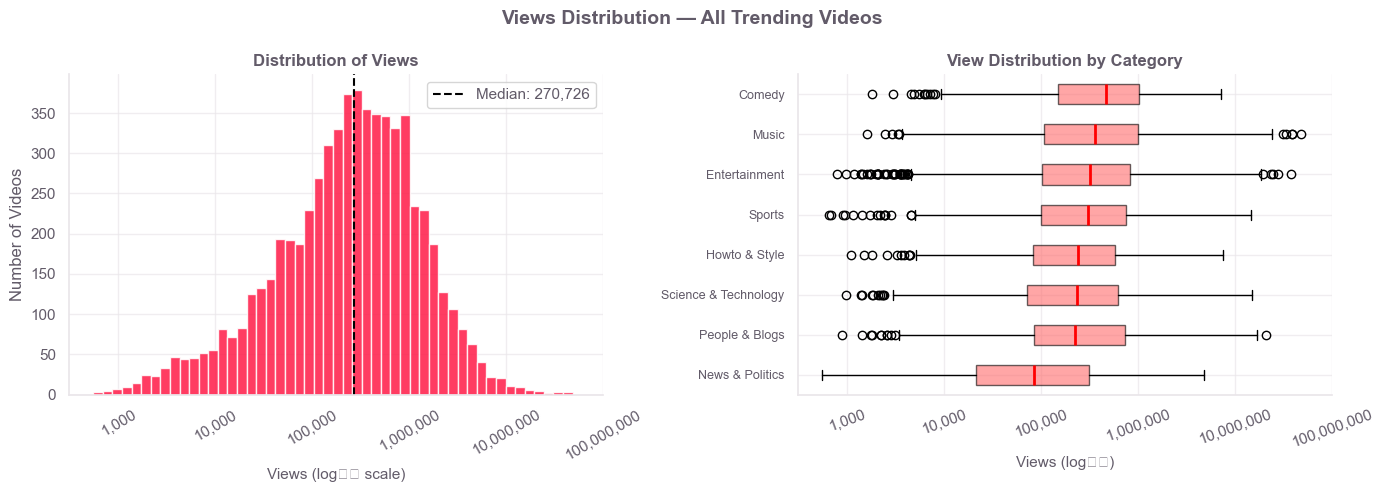

In [19]:
# 4.1 Views Distribution
# A log scale is used to better visualise the full range

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Views Distribution — All Trending Videos", fontsize=14, fontweight="bold")

# Left: Histogram on log scale
ax = axes[0]
log_views = np.log10(df_video["views"].clip(lower=1))
ax.hist(log_views, bins=50, color=YOUTUBE_RED, edgecolor="white", alpha=0.85)
ax.set_xlabel("Views (log₁₀ scale)", fontsize=11)
ax.set_ylabel("Number of Videos")
ax.set_title("Distribution of Views")
# Add tick labels showing actual view counts
ticks = [3, 4, 5, 6, 7, 8]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{10**t:,.0f}" for t in ticks], rotation=30)
ax.axvline(np.log10(df_video["views"].median()), color="black", linestyle="--", label=f"Median: {df_video['views'].median():,.0f}", linewidth=1.5)
ax.legend()

# Right: Box plots by category (top 8 categories by count)
ax = axes[1]
top_cats = df_video["category"].value_counts().head(8).index
df_top   = df_video[df_video["category"].isin(top_cats)]
cat_median_order = df_top.groupby("category")["views"].median().sort_values().index

data_to_plot = [np.log10(df_top[df_top["category"] == c]["views"].clip(lower=1)) for c in cat_median_order]
bp = ax.boxplot(data_to_plot, vert=False, patch_artist=True,
                medianprops=dict(color="red", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("#FF6B6B")
    patch.set_alpha(0.6)
ax.set_yticklabels(cat_median_order, fontsize=9)
ax.set_xlabel("Views (log₁₀)", fontsize=11)
ax.set_title("View Distribution by Category")
ticks = [3, 4, 5, 6, 7, 8]
ax.set_xticks(ticks)
ax.set_xticklabels([f"{10**t:,.0f}" for t in ticks], rotation=20)

plt.tight_layout()
plt.savefig("charts/04_views_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Key insight:**
- The distribution appears broadly consistent with a power-law pattern, where a small number of viral videos dominate the platform while most videos receive comparatively modest view counts.
- Category performance also varies. Comedy and Music show the highest typical view counts, while Music and Entertainment exhibit the most extreme viral outliers.


In [20]:
# 4.2 Category Performance
# Compare categories on three metrics:
# 1. Video count (how often does this category appear on trending)
# 2. Median views (how big is the typical audience)
# 3. Median engagement score (how actively does the audience respond)

cat_stats = (
    df_video.groupby("category")
    .agg(
        video_count      = ("video_id",         "count"),
        median_views     = ("views",             "median"),
        median_engagement= ("engagement_score",  "median"),
        median_like_rate = ("like_rate",         "median"),
    )
    .sort_values("median_views", ascending=False)
    .round(4)
)

# Add a share column
cat_stats["share_%"] = (cat_stats["video_count"] / cat_stats["video_count"].sum() * 100).round(1)
cat_stats["median_views_M"] = (cat_stats["median_views"] / 1e6).round(2)

print("Category Performance Summary:")
display_cols = ["video_count", "share_%", "median_views_M", "median_engagement", "median_like_rate"]
print(cat_stats[display_cols].rename(columns={
    "video_count": "# Videos",
    "share_%": "Share %",
    "median_views_M": "Median Views (M)",
    "median_engagement": "Engagement Score",
    "median_like_rate": "Like Rate"
}).to_string())


Category Performance Summary:
                       # Videos  Share %  Median Views (M)  Engagement Score  Like Rate
category                                                                               
Gaming                      103      1.6              0.65            0.0502     0.0414
Comedy                      547      8.6              0.47            0.0466     0.0424
Shows                         4      0.1              0.38            0.0338     0.0283
Film & Animation            317      5.0              0.36            0.0328     0.0273
Music                       799     12.6              0.36            0.0699     0.0646
Entertainment              1617     25.5              0.32            0.0285     0.0250
Sports                      451      7.1              0.31            0.0145     0.0114
Howto & Style               595      9.4              0.24            0.0544     0.0492
Science & Technology        380      6.0              0.24            0.0366     0.0320
Ed

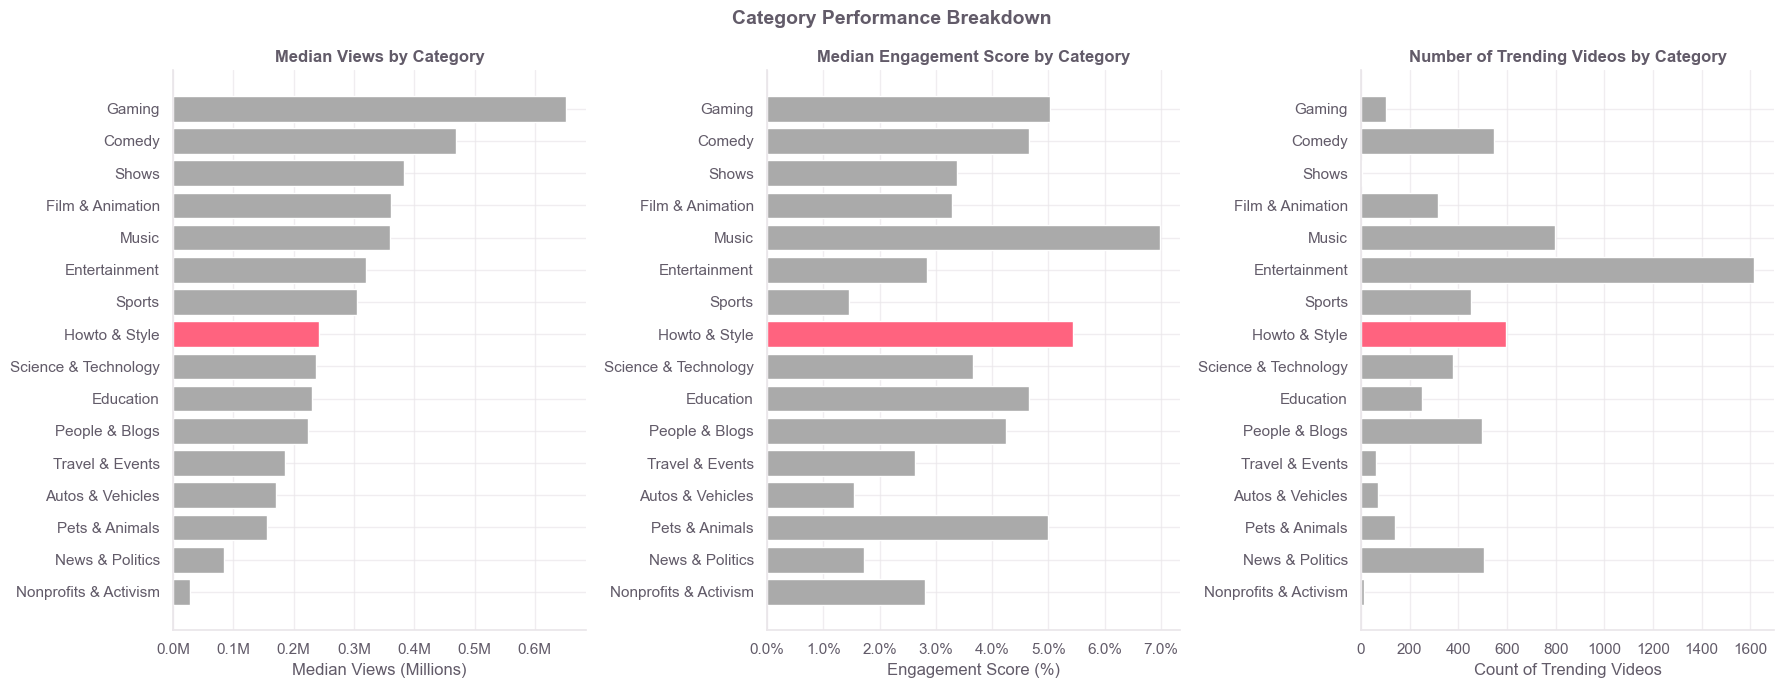

In [21]:
# 4.3 Category Charts

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Category Performance Breakdown", fontsize=14, fontweight="bold")

# Sort by median views for consistent ordering
sorted_cats = cat_stats["median_views"].sort_values()

# Colours: highlight Howto & Style (beauty) in pink
colors = [BEAUTY_PINK if c == "Howto & Style" else "#AAAAAA" for c in sorted_cats.index]

# Chart 1: Median views
ax = axes[0]
ax.barh(sorted_cats.index, sorted_cats.values / 1e6, color=colors)
ax.set_title("Median Views by Category")
ax.set_xlabel("Median Views (Millions)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# Chart 2: Engagement score
ax = axes[1]
eng_sorted = cat_stats["median_engagement"].reindex(sorted_cats.index)
ax.barh(sorted_cats.index, eng_sorted.values * 100,
        color=[BEAUTY_PINK if c == "Howto & Style" else "#AAAAAA" for c in sorted_cats.index])
ax.set_title("Median Engagement Score by Category")
ax.set_xlabel("Engagement Score (%)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# Chart 3: Video count
ax = axes[2]
count_sorted = cat_stats["video_count"].reindex(sorted_cats.index)
ax.barh(sorted_cats.index, count_sorted.values,
        color=[BEAUTY_PINK if c == "Howto & Style" else "#AAAAAA" for c in sorted_cats.index])
ax.set_title("Number of Trending Videos by Category")
ax.set_xlabel("Count of Trending Videos")

plt.tight_layout()
plt.savefig("charts/04_category_performance.png", dpi=150, bbox_inches="tight")
plt.show()

**Key insight:**
- Howto & Style (pink bars) punches above its weight — while it does not dominate trending volume or raw views, it achieves comparatively strong engagement levels. 
- This suggests beauty-related content attracts a more actively engaged audience rather than relying purely on scale.

**Key insight:**
    High total views are driven in different ways across channels. Creator-led and music-focused channels achieve massive reach with relatively few videos, while traditional media channels rely more heavily on upload volume. Music-related channels also show substantially stronger audience engagement.

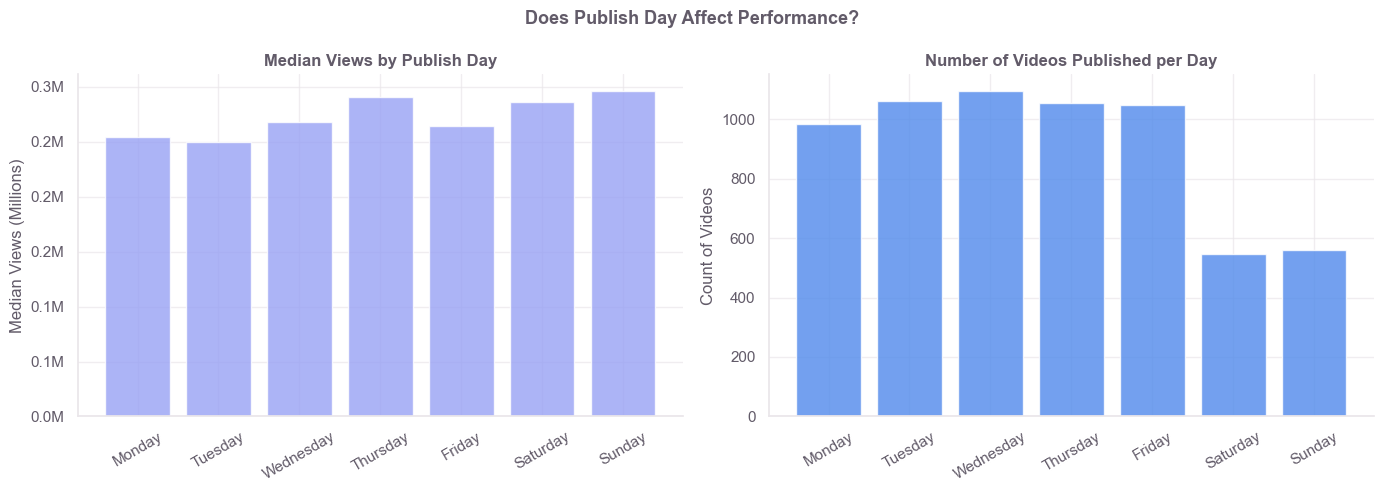

Publish day statistics:
             median_views  video_count
publish_day                           
Monday           254444.0          985
Tuesday          250242.0         1061
Wednesday        268505.0         1096
Thursday         290408.5         1054
Friday           264767.0         1047
Saturday         286563.5          546
Sunday           296633.0          559


In [22]:
# 4.4 Publish Day vs Performance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Does Publish Day Affect Performance?", fontsize=13, fontweight="bold")

day_stats = (
    df_video.groupby("publish_day", observed=True)
    .agg(median_views=("views", "median"), video_count=("video_id", "count"))
)

# Chart 1: Median views by publish day
ax = axes[0]
ax.bar(day_stats.index, day_stats["median_views"] / 1e6, color=FADE_BLUE, alpha=0.8)
ax.set_title("Median Views by Publish Day")
ax.set_ylabel("Median Views (Millions)")
ax.tick_params(axis="x", rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

# Chart 2: Volume published per day
ax = axes[1]
ax.bar(day_stats.index, day_stats["video_count"], color=BABY_BLUE, alpha=0.8)
ax.set_title("Number of Videos Published per Day")
ax.set_ylabel("Count of Videos")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("charts/04_publish_day.png", dpi=150, bbox_inches="tight")
plt.show()

print("Publish day statistics:")
print(day_stats.to_string())


**Key insight:** 
Videos published on weekends achieve strong median view performance despite lower publishing volume. This suggests weekend uploads may face less competition for audience attention compared with weekdays, when upload activity is substantially higher.

### Engagement vs Reach (A Platform-Wide Disconnect)

This correlation analysis establishes the central analytical finding that motivates the remainder of the notebook: audience engagement and raw reach are only weakly related across trending YouTube content.

This is strategically important because creator partnerships are often evaluated primarily on visibility metrics such as views or subscriber count. If engagement behaves differently from reach at the platform level, then a creator selection process built entirely around audience size may systematically overlook highly responsive audiences.

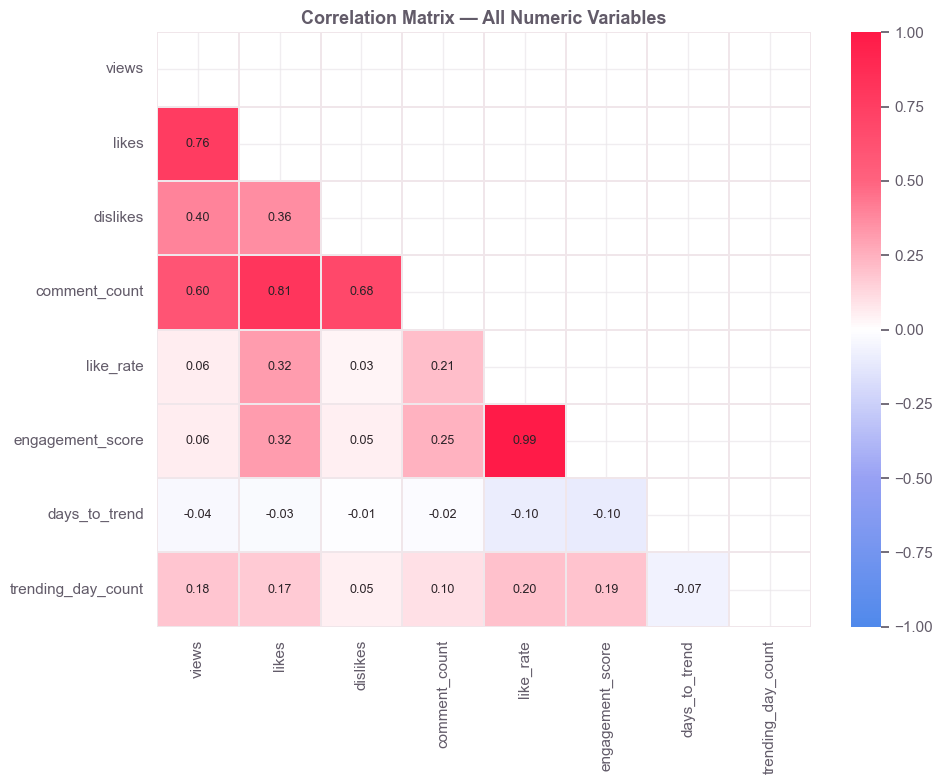

Correlation with views (sorted):
  likes                   +0.761  ███████████████████
  comment_count           +0.600  ██████████████
  dislikes                +0.396  █████████
  trending_day_count      +0.181  ████
  like_rate               +0.059  █
  engagement_score        +0.056  █
  days_to_trend           -0.035  


In [23]:
# 4.5 Correlation Analysis
# What numeric variables are most related to views?

from matplotlib.colors import LinearSegmentedColormap

corr_cols = ["views", "likes", "dislikes", "comment_count",
             "like_rate", "engagement_score", "days_to_trend", "trending_day_count"]
corr_matrix = df_video[corr_cols].corr()

custom_cmap = LinearSegmentedColormap.from_list(
    "youtube_palette_1",
    ["#5089EB", "#98A1F4", "#FFFFFF", "#FF637F", "#FF1A47"]
)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap=custom_cmap, center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, linecolor="#F0E6EA",
    annot_kws={"size": 9, "color": "#2B2328"}
)
ax.set_title("Correlation Matrix — All Numeric Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with views (sorted):")
corr_views = corr_matrix["views"].drop("views").sort_values(ascending=False)
for col, val in corr_views.items():
    bar = "█" * int(abs(val) * 25)
    sign = "+" if val >= 0 else "-"
    print(f"  {col:<22}  {sign}{abs(val):.3f}  {bar}")

**Key insight:**
- Likes and comment counts are highly correlated with views (expected).
- Engagement_score shows almost no correlation with raw view counts, which means views and quality of engagement are measuring different things.

---
## 5. Beauty Content Deep Dive

This section focuses specifically on beauty-related content. The analysis starts by comparing beauty videos against other categories, then digs into what makes the best beauty content stand out.

Because direct conversion or sales data are unavailable in the dataset, engagement_score is used throughout this section as a proxy for audience responsiveness and potential creator influence. While imperfect, it provides a defensible approximation of audience responsiveness in the absence of direct conversion or sales data.

In [24]:
# 5.1 Isolate beauty content
df_beauty     = df_video[df_video["is_beauty"]].copy()
df_non_beauty = df_video[~df_video["is_beauty"]].copy()

print(f"Beauty videos      : {len(df_beauty):,}")
print(f"Non-beauty videos  : {len(df_non_beauty):,}")
print(f"Beauty share of trending videos: {len(df_beauty)/len(df_video)*100:.1f}%")
print()
print("Beauty video metrics:")
beauty_summary = pd.DataFrame({
    "Metric": [
        "Median Views",
        "Median Likes",
        "Median Comments",
        "Median Like Rate",
        "Median Engagement",
        "Median Days to Trend"
    ],
    "Value": [
        f"{df_beauty['views'].median():,.0f}",
        f"{df_beauty['likes'].median():,.0f}",
        f"{df_beauty['comment_count'].median():,.0f}",
        f"{df_beauty['like_rate'].median()*100:.2f}%",
        f"{df_beauty['engagement_score'].median()*100:.2f}%",
        f"{df_beauty['days_to_trend'].median():.0f} days"
    ]
})
display(beauty_summary)

Beauty videos      : 823
Non-beauty videos  : 5,525
Beauty share of trending videos: 13.0%

Beauty video metrics:


,Metric,Value
0,Median Views,"260,560"
1,Median Likes,"12,410"
2,Median Comments,"1,107"
3,Median Like Rate,4.92%
4,Median Engagement,5.45%
5,Median Days to Trend,2 days


Metric,Beauty,Non-Beauty,Beauty vs Non (%)
Median Views,0.26,0.27,-4.3%
Median Likes,12.41,7.45,+66.7%
Median Like Rate,4.92,2.86,+72.4%
Median Engagement,5.45,3.32,+64.1%
Median Days to Trend,2.00,2.00,+0.0%


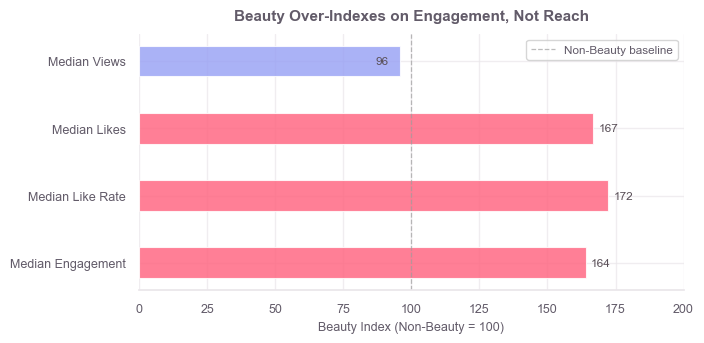

In [25]:
# 5.2 Beauty vs. Non-Beauty Comparison

comparison_rows = []

metrics = {
    "Median Views":        ("views",            1e-6, "M"),
    "Median Likes":        ("likes",            1e-3, "K"),
    "Median Like Rate":    ("like_rate",        100,  "%"),
    "Median Engagement":   ("engagement_score", 100,  "%"),
    "Median Days to Trend":("days_to_trend",    1,    "days"),
}

for label, (col, scale, unit) in metrics.items():
    beauty_val = df_beauty[col].median() * scale
    non_val    = df_non_beauty[col].median() * scale
    diff_pct   = ((beauty_val - non_val) / non_val * 100) if non_val != 0 else np.nan
    index_val  = (beauty_val / non_val * 100) if non_val != 0 else np.nan
    
    comparison_rows.append({
        "Metric": label,
        "Beauty": beauty_val,
        "Non-Beauty": non_val,
        "Beauty vs Non (%)": diff_pct,
        "Beauty Index": index_val,
        "Unit": unit
    })

comparison_df = pd.DataFrame(comparison_rows)

display(
    comparison_df[["Metric", "Beauty", "Non-Beauty", "Beauty vs Non (%)"]]
    .style
    .format({
        "Beauty": "{:.2f}",
        "Non-Beauty": "{:.2f}",
        "Beauty vs Non (%)": "{:+.1f}%"
    })
    .hide(axis="index")
)

# Compact indexed comparison chart
# Non-Beauty baseline = 100

chart_df = comparison_df[
    comparison_df["Metric"] != "Median Days to Trend"
].copy()

chart_df["Metric"] = pd.Categorical(
    chart_df["Metric"],
    categories=["Median Views", "Median Likes", "Median Like Rate", "Median Engagement"],
    ordered=True
)
chart_df = chart_df.sort_values("Metric", ascending=False)

fig, ax = plt.subplots(figsize=(7.2, 3.6))

colors = [
    BEAUTY_PINK if v >= 100 else FADE_BLUE
    for v in chart_df["Beauty Index"]
]

bars = ax.barh(
    chart_df["Metric"],
    chart_df["Beauty Index"],
    color=colors,
    alpha=0.82,
    height=0.46,
    edgecolor="white",
    linewidth=0.8
)

ax.axvline(
    100,
    color="#9E9E9E",
    linestyle="--",
    linewidth=0.9,
    label="Non-Beauty baseline",
    alpha=0.7
)

ax.set_title(
    "Beauty Over-Indexes on Engagement, Not Reach",
    fontsize=11,
    fontweight="bold",
    pad=10
)
ax.set_xlabel("Beauty Index (Non-Beauty = 100)", fontsize=9)
ax.set_ylabel("")
ax.set_xlim(0, 200)

for bar, val in zip(bars, chart_df["Beauty Index"]):

    if val < 100:
        x_pos = val - 4
        align = "right"
    else:
        x_pos = val + 2
        align = "left"

    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f}",
        va="center",
        ha=align,
        fontsize=8.5,
        fontweight="normal",
        color="#5A5058"
    )

ax.legend(
    frameon=True,
    loc="upper right",
    fontsize=8.5
)

ax.tick_params(axis="both", labelsize=9)
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.savefig("charts/05_beauty_vs_nonbeauty_index.png", dpi=150, bbox_inches="tight")
plt.show()

**Key insight:** Beauty content does not outperform non-beauty content on raw reach, but it clearly over-indexes on audience response metrics such as like rate and engagement score. This suggests that beauty content may be more valuable for community-building and creator partnerships than for pure awareness campaigns.

In [26]:
# 5.3 Top Beauty Channels
# Reference table for creator-level performance before mapping reach vs engagement.

beauty_channels = (
    df_beauty.groupby("channel_title")
    .agg(
        video_count       = ("video_id",         "count"),
        total_views       = ("views",            "sum"),
        median_views      = ("views",            "median"),
        avg_engagement    = ("engagement_score", "mean"),
        avg_like_rate     = ("like_rate",        "mean"),
        avg_days_to_trend = ("days_to_trend",    "mean"),
    )
    .sort_values("total_views", ascending=False)
    .head(15)
    .copy()
)

beauty_channels["total_views_M"]    = beauty_channels["total_views"] / 1e6
beauty_channels["median_views_M"]   = beauty_channels["median_views"] / 1e6
beauty_channels["avg_engagement_%"] = beauty_channels["avg_engagement"] * 100
beauty_channels["avg_like_rate_%"]  = beauty_channels["avg_like_rate"] * 100

print("Top Beauty Channels — Reference Summary:\n")

display(
    beauty_channels[[
        "video_count",
        "total_views_M",
        "median_views_M",
        "avg_engagement_%",
        "avg_like_rate_%",
        "avg_days_to_trend"
    ]]
    .rename(columns={
        "video_count":        "# Videos",
        "total_views_M":      "Total Views (M)",
        "median_views_M":     "Median Views (M)",
        "avg_engagement_%":   "Avg Engagement %",
        "avg_like_rate_%":    "Avg Like Rate %",
        "avg_days_to_trend":  "Avg Days to Trend",
    })
    .style
    .format({
        "Total Views (M)":     "{:.1f}",
        "Median Views (M)":    "{:.2f}",
        "Avg Engagement %":    "{:.2f}%",
        "Avg Like Rate %":     "{:.2f}%",
        "Avg Days to Trend":   "{:.1f}",
    })
    .background_gradient(subset=["Avg Engagement %"], cmap="RdPu")
)

Top Beauty Channels — Reference Summary:



,# Videos,Total Views (M),Median Views (M),Avg Engagement %,Avg Like Rate %,Avg Days to Trend
channel_title,,,,,,
Safiya Nygaard,9,27.6,2.82,6.65%,5.50%,2.4
Simply Nailogical,12,23.5,1.87,6.48%,5.73%,2.3
James Charles,14,21.3,1.51,9.94%,8.48%,2.5
Tasty,24,20.1,0.80,3.75%,3.55%,2.2
NikkieTutorials,12,19.8,1.52,9.91%,7.96%,2.2
First We Feast,31,17.8,0.45,4.52%,4.01%,1.8
5-Minute Crafts,3,11.7,4.47,1.07%,0.99%,1.3
Vogue,14,10.0,0.45,5.10%,4.88%,3.4
Tati,15,9.3,0.57,6.34%,5.61%,1.9


**Key insight:**  
Reach and engagement do not always move together across beauty creators. Some large channels dominate total views, while smaller personality-driven creators generate disproportionately strong audience interaction. The next section maps this relationship directly to identify channels that combine high engagement with comparatively lower reach.

*Note:* The beauty segment includes both direct beauty creators and broader beauty-adjacent lifestyle content identified through category labels and keyword matching. As a result, some lifestyle or DIY-oriented channels may also appear in the analysis.

Channels included: 40
Median total views: 4.84M
Median engagement: 6.65%


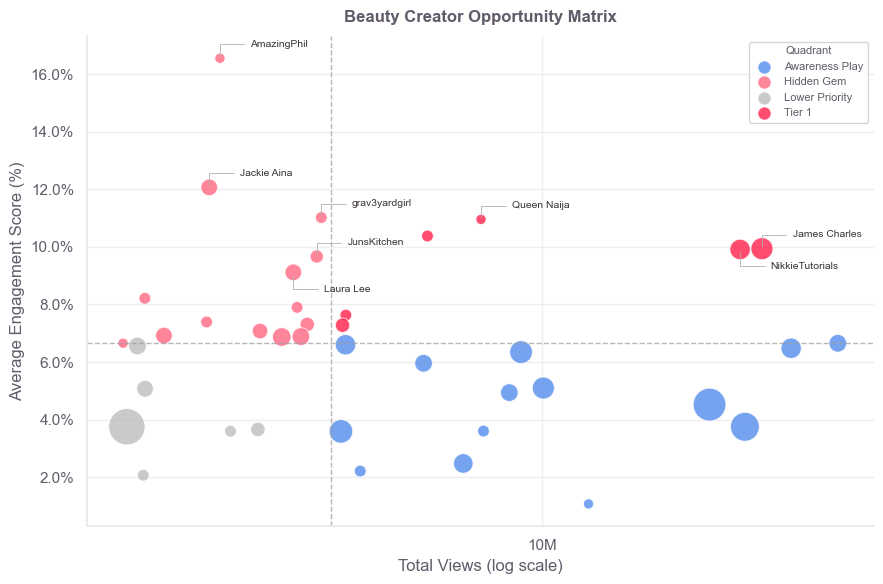


Hidden-Gem Beauty Channels (Ranked by Engagement)


Channel,# Videos,Total Views (M),Avg Engagement %,Avg Like Rate %,Avg Days to Trend
AmazingPhil,3,3.30,16.55%,14.62%,3.0
Jackie Aina,8,3.18,12.07%,10.72%,1.4
grav3yardgirl,4,4.67,11.02%,8.79%,1.5
JunsKitchen,5,4.60,9.67%,8.99%,1.2
Laura Lee,8,4.25,9.12%,5.52%,2.1
Miranda Sings,4,2.55,8.22%,7.36%,3.0
AlishaMarie,4,4.30,7.90%,6.80%,2.5
Jaclyn Hill,4,3.15,7.39%,6.47%,1.5
Zoella,6,4.45,7.31%,6.87%,2.5
Mr. Kate,7,3.79,7.08%,6.60%,2.4


In [27]:
# 5.4 Hidden-Gem Creator Analysis
# Channels with above-median engagement but below-median reach
# may represent higher-efficiency partnership opportunities

beauty_channel_stats = (
    df_beauty.groupby("channel_title")
    .agg(
        video_count       = ("video_id", "count"),
        total_views       = ("views", "sum"),
        avg_engagement    = ("engagement_score", "mean"),
        avg_like_rate     = ("like_rate", "mean"),
        avg_days_to_trend = ("days_to_trend", "mean"),
    )
    .reset_index()
)

beauty_channel_stats = (
    beauty_channel_stats[beauty_channel_stats["video_count"] >= 3]
    .nlargest(40, "total_views")
    .copy()
)


# Quadrant dividing
med_views = beauty_channel_stats["total_views"].median()
med_eng   = beauty_channel_stats["avg_engagement"].median()

beauty_channel_stats["quadrant"] = np.select(
    [
        (beauty_channel_stats["total_views"] >= med_views) & (beauty_channel_stats["avg_engagement"] >= med_eng),
        (beauty_channel_stats["total_views"] <  med_views) & (beauty_channel_stats["avg_engagement"] >= med_eng),
        (beauty_channel_stats["total_views"] >= med_views) & (beauty_channel_stats["avg_engagement"] <  med_eng),
    ],
    [
        "Tier 1",
        "Hidden Gem",
        "Awareness Play",
    ],
    default="Lower Priority"
)

print(f"Channels included: {len(beauty_channel_stats)}")
print(f"Median total views: {med_views/1e6:.2f}M")
print(f"Median engagement: {med_eng*100:.2f}%")


# Plotting
fig, ax = plt.subplots(figsize=(9, 6))

quadrant_colors = {
    "Tier 1": YOUTUBE_RED,
    "Hidden Gem": BEAUTY_PINK,
    "Awareness Play": BABY_BLUE,
    "Lower Priority": "#BBBBBB",
}

for q, group in beauty_channel_stats.groupby("quadrant"):
    ax.scatter(
        group["total_views"],
        group["avg_engagement"] * 100,
        s=group["video_count"] * 18,
        color=quadrant_colors[q],
        alpha=0.78,
        edgecolors="white",
        linewidths=0.7,
        label=q
    )

ax.axvline(med_views, color="#9E9E9E", linestyle="--", linewidth=1, alpha=0.75)
ax.axhline(med_eng * 100, color="#9E9E9E", linestyle="--", linewidth=1, alpha=0.75)
sns.despine(ax=ax)

# Label selected channels
label_targets = pd.concat([
    beauty_channel_stats[beauty_channel_stats["quadrant"] == "Hidden Gem"]
    .nlargest(5, "avg_engagement"),
    beauty_channel_stats[beauty_channel_stats["quadrant"] == "Tier 1"]
    .nlargest(3, "total_views")
])

for _, row in label_targets.iterrows():

    # Default label position
    offset = (22, 10)

    # Manual tweaks for overlapping labels
    if row["channel_title"] in ["Laura Lee", "NikkieTutorials"]:
        offset = (22, -12)

    ax.annotate(
        row["channel_title"],
        xy=(row["total_views"], row["avg_engagement"] * 100),
        xytext=offset,
        textcoords="offset points",
        fontsize=7.5,
        color="#3A3338",
        ha="left",
        va="center",
        arrowprops=dict(
            arrowstyle="-",
            color="#B0B0B0",
            linewidth=0.7,
            alpha=0.85,
            connectionstyle="angle,angleA=0,angleB=90,rad=0"
        )
    )
    
ax.set_xscale("log")
ax.set_title("Beauty Creator Opportunity Matrix", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Total Views (log scale)")
ax.set_ylabel("Average Engagement Score (%)")

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f}%")
)

legend = ax.legend(
    title="Quadrant",
    fontsize=8,
    title_fontsize=8,
    loc="upper right",
    frameon=True,
)

# Make all legend bubbles equal size
for handle in legend.legend_handles:
    handle.set_sizes([90])


plt.tight_layout()
plt.savefig("charts/05_hidden_gem_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


# Summary Table for Hidden Gems
hidden_gem_table = (
    beauty_channel_stats[beauty_channel_stats["quadrant"] == "Hidden Gem"]
    .sort_values("avg_engagement", ascending=False)
    .copy()
)

hidden_gem_table["total_views_M"]    = hidden_gem_table["total_views"] / 1e6
hidden_gem_table["avg_engagement_%"] = hidden_gem_table["avg_engagement"] * 100
hidden_gem_table["avg_like_rate_%"]  = hidden_gem_table["avg_like_rate"] * 100

print()
print("Hidden-Gem Beauty Channels (Ranked by Engagement)")

display(
    hidden_gem_table[[
        "channel_title", "video_count", "total_views_M",
        "avg_engagement_%", "avg_like_rate_%", "avg_days_to_trend"
    ]]
    .rename(columns={
        "channel_title": "Channel",
        "video_count": "# Videos",
        "total_views_M": "Total Views (M)",
        "avg_engagement_%": "Avg Engagement %",
        "avg_like_rate_%": "Avg Like Rate %",
        "avg_days_to_trend": "Avg Days to Trend"
    })
    .style
    .hide(axis="index")
    .format({
        "Total Views (M)": "{:.2f}",
        "Avg Engagement %": "{:.2f}%",
        "Avg Like Rate %": "{:.2f}%",
        "Avg Days to Trend": "{:.1f}"
    })
    .background_gradient(subset=["Avg Engagement %"], cmap="RdPu")
)


**Key insight:**
The matrix separates channels that *look large* from channels that *deliver highly responsive audiences*. Tier 1 creators (top-right) are the natural default for large-scale brand awareness campaigns because they combine strong reach with strong engagement — but their partnership costs are also likely to reflect that visibility.

The hidden-gem quadrant (top-left) is strategically different. These creators generate above-median engagement despite remaining below the median on total reach, suggesting that audience responsiveness does not scale proportionally with visibility. For a beauty brand operating under a fixed influencer budget, these channels may offer a materially stronger engagement-per-pound-spent tradeoff than the obvious top-tier choices, particularly for product launches, conversion-focused campaigns, and partnerships where audience trust matters more than maximum impression volume.

By contrast, Awareness Play channels (bottom-right) may still be useful for campaigns where broad exposure is the primary objective, but they appear less efficient when audience interaction is the core KPI.

> **Caveat:** Channel names and rankings reflect 2017–2018 trending activity and should be treated as illustrative of the methodology rather than a current partnership shortlist. Engagement rate also acts only as a proxy for audience responsiveness — not a direct measure of purchase intent or conversion. Any real partnership decision should incorporate qualitative review of content style, audience demographics, and brand alignment, none of which are visible in this dataset.

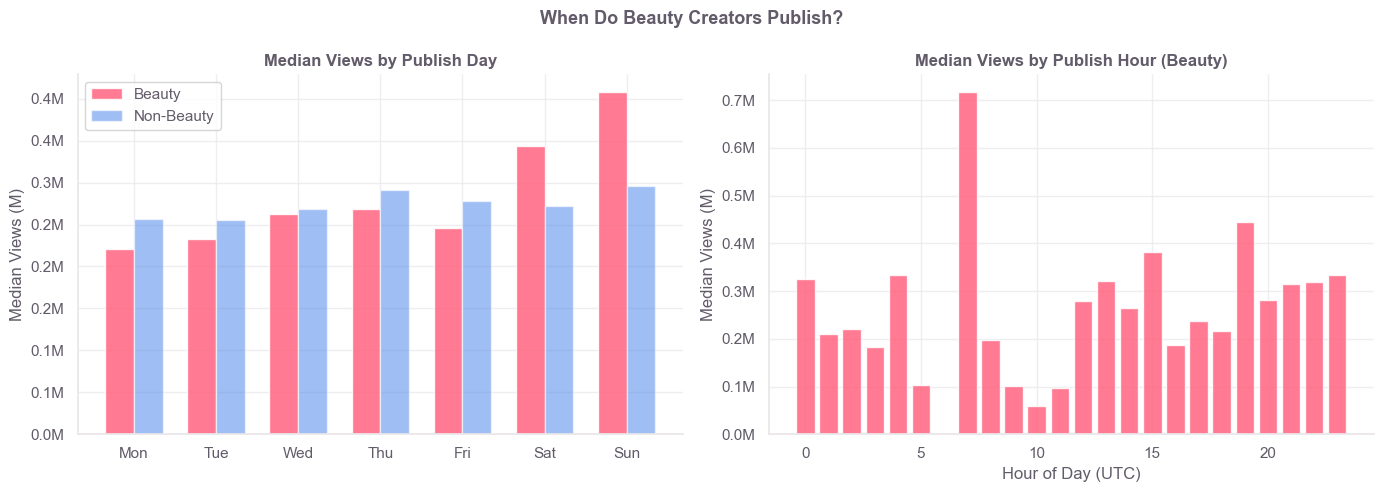

Highest median-view upload hour observed: 7:00 UTC
Highest median-view publish day observed: Sunday (0.41M views)


In [28]:
# 5.5 Beauty timing
# Upload timing patterns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("When Do Beauty Creators Publish?", fontsize=13, fontweight="bold")

# Day of week
ax = axes[0]
beauty_day = df_beauty.groupby("publish_day", observed=True)["views"].median() / 1e6
non_beauty_day = df_non_beauty.groupby("publish_day", observed=True)["views"].median() / 1e6

x = np.arange(len(day_order))
width = 0.35
ax.bar(x - width/2, beauty_day.reindex(day_order),     width, label="Beauty",     color=BEAUTY_PINK,   alpha=0.85)
ax.bar(x + width/2, non_beauty_day.reindex(day_order), width, label="Non-Beauty", color=BABY_BLUE,     alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in day_order])
ax.set_title("Median Views by Publish Day")
ax.set_ylabel("Median Views (M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.legend()

# Hour of day
ax = axes[1]
beauty_hour = df_beauty.groupby("publish_hour")["views"].median() / 1e6
ax.bar(beauty_hour.index, beauty_hour.values, color=BEAUTY_PINK, alpha=0.85)
ax.set_title("Median Views by Publish Hour (Beauty)")
ax.set_xlabel("Hour of Day (UTC)")
ax.set_ylabel("Median Views (M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))

best_hour = beauty_hour.idxmax()

plt.tight_layout()
plt.savefig("charts/05_beauty_timing.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Highest median-view upload hour observed: {best_hour}:00 UTC")
print(
    f"Highest median-view publish day observed: "
    f"{beauty_day.idxmax()} ({beauty_day.max():.2f}M views)"
)


**Key insight:** Beauty content performs noticeably better on weekends, while non-beauty content remains relatively stable across the week. This may suggest that audiences engage with beauty content more heavily during weekend browsing periods, although the pattern could also be influenced by creator schedules, audience demographics, and category mix effects.

In [29]:
# 5.6 Top-performing beauty videos
# Look at the actual titles of the best beauty videos for qualitative insight

top_beauty = (
    df_beauty.nlargest(20, "views")[["title", "channel_title", "views",
                                     "like_rate", "engagement_score", "days_to_trend"]]
    .reset_index(drop=True)
)

top_beauty["views(M)"]     = (top_beauty["views"] / 1e6).round(1)
top_beauty["like_rate(%)"] = (top_beauty["like_rate"] * 100).round(1)
top_beauty["engagement(%)"]= (top_beauty["engagement_score"] * 100).round(1)

print("Top 20 Beauty Videos by Views:")

display(
    top_beauty[
        ["title", "channel_title", "views(M)",
         "like_rate(%)", "engagement(%)", "days_to_trend"]
    ]
    .rename(columns={
        "title": "Title",
        "channel_title": "Channel",
        "views(M)": "Views (M)",
        "like_rate(%)": "Like Rate (%)",
        "engagement(%)": "Engagement (%)",
        "days_to_trend": "Days to Trend"
    })
    .style
    .hide(axis="index")
    .format({
        "Views (M)": "{:.1f}",
        "Like Rate (%)": "{:.1f}",
        "Engagement (%)": "{:.1f}",
        "Days to Trend": "{:.0f}"
    })
)

Top 20 Beauty Videos by Views:


Title,Channel,Views (M),Like Rate (%),Engagement (%),Days to Trend
I Got 99 Problems But Being A Girl Ain't One! DIY Girls Hacks and More by Blossom,Blossom,7.6,0.7,0.8,2
John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,7.2,0.8,0.9,4
I Tried Cutting My Hair Off With A Sword Like Mulan,Boldly,6.5,2.6,2.8,3
MEDICINE - QUEEN NAIJA (OFFICIAL VIDEO),Queen Naija,6.5,10.0,11.8,3
42 HOLY GRAIL HACKS THAT WILL SAVE YOU A FORTUNE,5-Minute Crafts,6.3,1.1,1.2,1
PANCAKE ART CHALLENGE 4!!! Learn How To Make Mario Odyssey Star Wars Jedi Nintendo Food DIY Pancake,Collins Key,5.3,11.0,13.2,2
I Got A Perfect Makeover Based On My Features,Safiya Nygaard,4.8,5.5,6.0,3
Melting Every Lipstick From Sephora Together,Safiya Nygaard,4.8,6.4,13.1,2
50 TOTALLY CRAZY IDEAS YOU CAN ACTUALLY DIY,5-Minute Crafts,4.5,0.8,0.9,2
How Michael B. Jordan's Black Panther Makeup Was Done — Exclusive Behind The Scenes,INSIDER,4.4,1.4,1.4,2


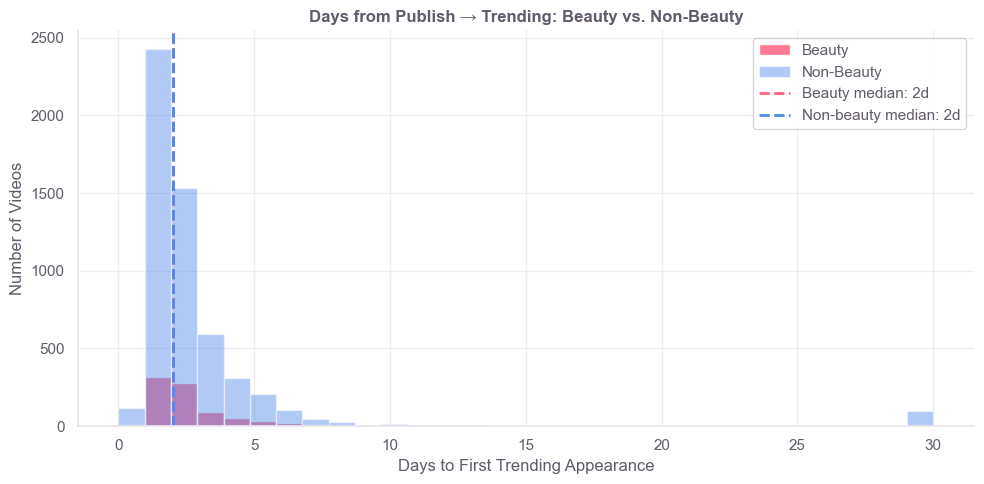

Beauty median days to trend   :  2 days
Non-beauty median days to trend: 2 days

Beauty videos trending within 2 days: 72.1%


In [30]:
# 5.7 Speed-to-viral in beauty content
# How quickly do top beauty videos trend?

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_beauty["days_to_trend"].clip(upper=30), bins=31,
        color=BEAUTY_PINK, edgecolor="white", alpha=0.85, label="Beauty")
ax.hist(df_non_beauty["days_to_trend"].clip(upper=30), bins=31,
        color=BABY_BLUE, edgecolor="white", alpha=0.45, label="Non-Beauty")
ax.axvline(df_beauty["days_to_trend"].median(), color=BEAUTY_PINK,
           linestyle="--", linewidth=2, label=f"Beauty median: {df_beauty['days_to_trend'].median():.0f}d")
ax.axvline(df_non_beauty["days_to_trend"].median(), color=BABY_BLUE,
           linestyle="--", linewidth=2, label=f"Non-beauty median: {df_non_beauty['days_to_trend'].median():.0f}d")
ax.set_title("Days from Publish → Trending: Beauty vs. Non-Beauty", fontsize=12, fontweight="bold")
ax.set_xlabel("Days to First Trending Appearance")
ax.set_ylabel("Number of Videos")
ax.legend()
plt.tight_layout()
plt.savefig("charts/05_days_to_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Beauty median days to trend   : {df_beauty['days_to_trend'].median():>2.0f} days")
print(f"Non-beauty median days to trend: {df_non_beauty['days_to_trend'].median():>1.0f} days")
print()
print(f"Beauty videos trending within 2 days: "
      f"{(df_beauty['days_to_trend'] <= 2).mean()*100:.1f}%")


**Key insight:** Most trending videos (both beauty and non-beauty) reach the trending page within just a few days of publication. Although the distributions are broadly similar across categories, 72.1% of beauty videos reach the trending page within two days of publication. This reinforces the importance of early audience momentum, as the majority of trending performance is established during the first 48 hours.

**Summary:**
The beauty deep-dive identified which creators and content styles perform well within the category. The next question is broader: what characteristics separate top-performing videos across the platform overall? To answer this, the analysis now shifts from category-specific patterns to performance-tier segmentation.

---
## 6. Segment Content by Performance

This section divides videos into performance tiers based on views, then compares what separates the tiers. Rather than treating all videos as equal, the focus shifts toward understanding 
**what separates the top-performing videos from the rest**.

Segmentation reveals where the opportunity is. A beauty brand doesn't need to beat the median but they need to understand what the top tier looks like and work toward those patterns.


In [31]:
# 6.1 Create performance tiers
# We use quartile-based segmentation:
#   Viral  → top 10%  by views
#   High   → 10–40%
#   Medium → 40–70%
#   Low    → bottom 30%

p30 = df_video["views"].quantile(0.30)
p40 = df_video["views"].quantile(0.40)
p70 = df_video["views"].quantile(0.70)
p90 = df_video["views"].quantile(0.90)

def assign_tier(views):
    if views >= p90:
        return "Viral (Top 10%)"
    elif views >= p70:
        return "High (70th–90th %ile)"
    elif views >= p40:
        return "Medium (40th–70th %ile)"
    else:
        return "Low (Bottom 40%)"

df_video["performance_tier"] = df_video["views"].apply(assign_tier)

tier_order = ["Viral (Top 10%)", "High (70th–90th %ile)",
              "Medium (40th–70th %ile)", "Low (Bottom 40%)"]

print("Performance tier thresholds:")
print(f"  Viral  (top 10%)  : ≥ {p90:,.0f} views")
print(f"  High              : {p70:,.0f} – {p90:,.0f} views")
print(f"  Medium            : {p40:,.0f} – {p70:,.0f} views")
print(f"  Low  (bottom 40%) : < {p40:,.0f} views")
print()
print("Tier distribution:")
print(df_video["performance_tier"].value_counts())


Performance tier thresholds:
  Viral  (top 10%)  : ≥ 1,685,178 views
  High              : 610,435 – 1,685,178 views
  Medium            : 181,762 – 610,435 views
  Low  (bottom 40%) : < 181,762 views

Tier distribution:
performance_tier
Low (Bottom 40%)           2539
Medium (40th–70th %ile)    1904
High (70th–90th %ile)      1270
Viral (Top 10%)             635
Name: count, dtype: int64


Performance Tier — Behavioural Comparison:


,# Videos,Median Like Rate %,Median Engagement %,Median Days to Trend,Median Trending Duration,Beauty Content %
Performance Tier,,,,,,
Viral (Top 10%),635,3.83%,4.23%,2.0,7.0,8.5%
High (70th–90th %ile),1270,3.33%,3.72%,2.0,7.0,12.6%
Medium (40th–70th %ile),1904,3.29%,3.70%,2.0,6.0,14.4%
Low (Bottom 40%),2539,2.69%,3.29%,2.0,5.0,13.2%


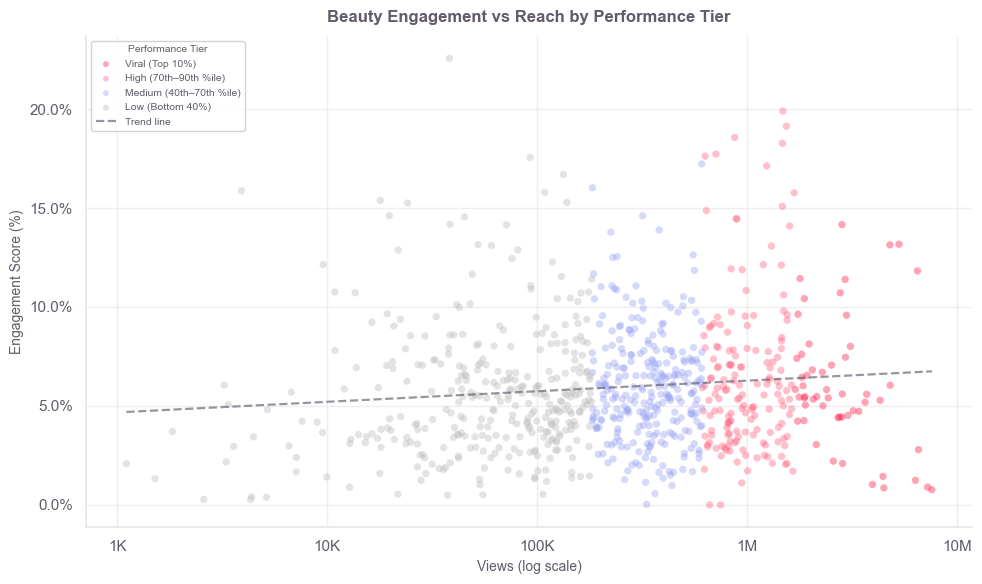

OLS slope on log(views): 0.5351  → engagement rate holds or increases with reach


In [32]:
# 6.2 Tier comparison — behavioural metrics, not views
# Since tiers are defined by views, this section focuses on engagement quality,
# speed to trend, trending duration, and beauty representation

tier_stats = (
    df_video.groupby("performance_tier")
    .agg(
        count              = ("video_id",           "count"),
        median_like_rate   = ("like_rate",          "median"),
        median_engagement  = ("engagement_score",   "median"),
        median_days_trend  = ("days_to_trend",      "median"),
        median_trend_days  = ("trending_day_count", "median"),
        pct_beauty         = ("is_beauty",          "mean"),
    )
    .reindex(tier_order)
    .round(4)
)

tier_stats["like_rate_%"]  = (tier_stats["median_like_rate"] * 100).round(2)
tier_stats["engagement_%"] = (tier_stats["median_engagement"] * 100).round(2)
tier_stats["beauty_%"]     = (tier_stats["pct_beauty"] * 100).round(1)

tier_display = (
    tier_stats[[
        "count", "like_rate_%", "engagement_%",
        "median_days_trend", "median_trend_days", "beauty_%"
    ]]
    .rename(columns={
        "count":             "# Videos",
        "like_rate_%":       "Median Like Rate %",
        "engagement_%":      "Median Engagement %",
        "median_days_trend": "Median Days to Trend",
        "median_trend_days": "Median Trending Duration",
        "beauty_%":          "Beauty Content %",
    })
)

tier_display.index.name = "Performance Tier"

print("Performance Tier — Behavioural Comparison:")
display(
    tier_display
    .style
    .format({
        "Median Like Rate %":         "{:.2f}%",
        "Median Engagement %":        "{:.2f}%",
        "Median Days to Trend":       "{:.1f}",
        "Median Trending Duration":   "{:.1f}",
        "Beauty Content %":           "{:.1f}%",
    })
    .background_gradient(subset=["Median Engagement %"], cmap="RdPu")
)


# Plotting — beauty videos only
# Explore whether engagement quality holds as reach scales

df_beauty_scatter = df_video[df_video["is_beauty"]].copy()

tier_color_map = {
    "Viral (Top 10%)":          YOUTUBE_RED,
    "High (70th–90th %ile)":   BEAUTY_PINK,
    "Medium (40th–70th %ile)": FADE_BLUE,
    "Low (Bottom 40%)":        "#BBBBBB",
}

fig, ax = plt.subplots(figsize=(10, 6))

for tier in tier_order:
    subset = df_beauty_scatter[df_beauty_scatter["performance_tier"] == tier]
    ax.scatter(
        subset["views"],
        subset["engagement_score"] * 100,
        color=tier_color_map[tier],
        label=tier,
        alpha=0.4,
        s=28,
        edgecolors="none",
        zorder=2,
    )

# Trend line using numpy polyfit on log-transformed views
log_views  = np.log10(df_beauty_scatter["views"].clip(lower=1))
engagement = df_beauty_scatter["engagement_score"] * 100

mask = np.isfinite(log_views) & np.isfinite(engagement)
coeffs = np.polyfit(log_views[mask], engagement[mask], deg=1)

trend_x_log = np.linspace(log_views[mask].min(), log_views[mask].max(), 200)
trend_y = np.polyval(coeffs, trend_x_log)

ax.plot(
    10 ** trend_x_log,
    trend_y,
    color="#625B69",
    linewidth=1.6,
    linestyle="--",
    alpha=0.65,
    label="Trend line",
    zorder=3,
)

ax.set_xscale("log")
ax.set_title(
    "Beauty Engagement vs Reach by Performance Tier",
    fontsize=12,
    fontweight="bold",
    pad=10
)
ax.set_xlabel("Views (log scale)", fontsize=10)
ax.set_ylabel("Engagement Score (%)", fontsize=10)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f}%")
)

ax.legend(
    title="Performance Tier",
    title_fontsize=7.5,
    fontsize=7.5,
    loc="upper left",
    frameon=True,
    framealpha=0.85,
    markerscale=0.8
)

sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("charts/06_engagement_vs_reach_beauty.png", dpi=150, bbox_inches="tight")
plt.show()

direction = "declines" if coeffs[0] < 0 else "holds or increases"
print(f"OLS slope on log(views): {coeffs[0]:.4f}  → engagement rate {direction} with reach")

**Key insight:**

The summary table shows that viral-tier videos trend faster *and* sustain their position longer — suggesting early momentum compounds rather than fades. The like rate and engagement score differences across tiers are real, but smaller than the view gap between tiers, which indicates that audience quality does not perfectly track audience size.

The scatter tells a more precise story for beauty content specifically. The trend line direction — readable from the OLS slope printed above — shows whether engagement rate holds as reach scales. If the slope is negative, even modestly, it supports the case for prioritising mid-size creators (the hidden-gem logic from Section 5.8): a brand gets proportionally more audience interaction per view from smaller channels than from the largest ones.

> **Caveat:** The trend line here is descriptive, not causal. High-engagement videos may attract more views precisely *because* of their engagement — the direction of influence cannot be resolved from this cross-sectional data alone.

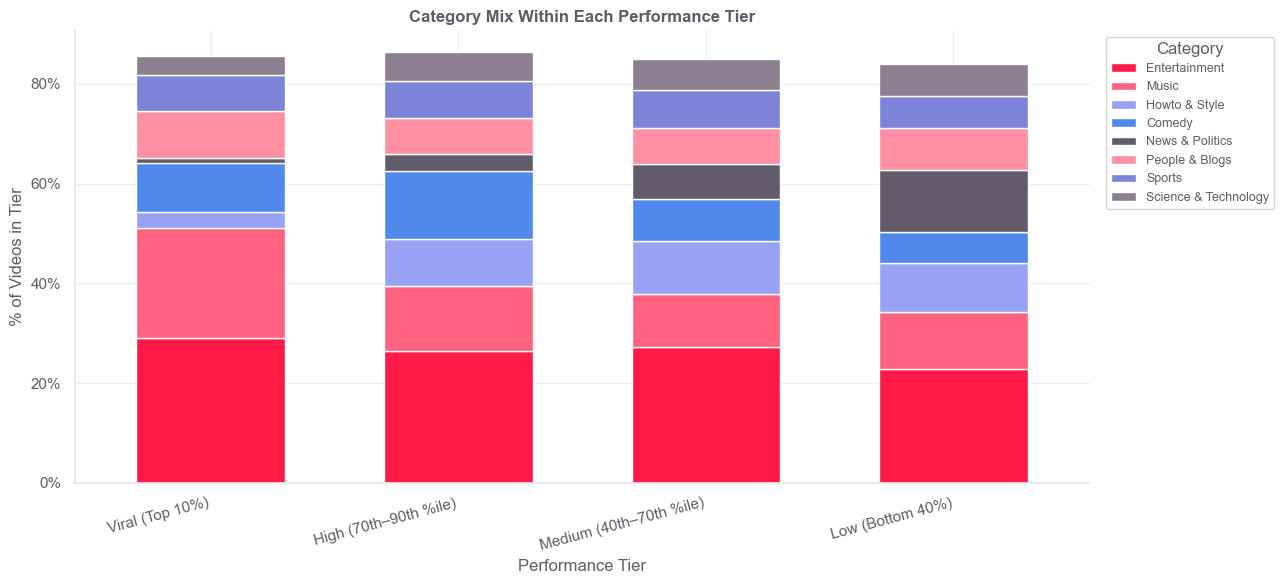

In [33]:
# 6.3 Category makeup within tiers
# What types of content dominate the viral tier vs the low tier

tier_cat = (
    df_video.groupby(["performance_tier", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(tier_order)
)

# Convert to percentages within each tier
tier_cat_pct = tier_cat.div(tier_cat.sum(axis=1), axis=0) * 100

# Only show top 8 categories for readability
top8 = df_video["category"].value_counts().head(8).index
tier_cat_pct_top8 = tier_cat_pct[top8]

youtube_palette_2 = [
    "#FF1A47",  # primary
    "#FF637F",  # secondary
    "#98A1F4",  # lavender
    "#5089EB",  # blue
    "#625B69",  # neutral
    "#FF8FA3",  # soft pink
    "#7C83D8",  # muted periwinkle
    "#8C7F8F"   # soft grey-purple
]

fig, ax = plt.subplots(figsize=(13, 6))
tier_cat_pct_top8.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=youtube_palette_2,
    width=0.6,
    edgecolor="white"
)
ax.set_title("Category Mix Within Each Performance Tier", fontsize=12, fontweight="bold")
ax.set_xlabel("Performance Tier")
ax.set_ylabel("% of Videos in Tier")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Category", fontsize=9)
ax.set_xticklabels(tier_order, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig("charts/06_tier_category_mix.png", dpi=150, bbox_inches="tight")
plt.show()

Beauty vs. Overall — Performance Tier Distribution:
                         Beauty %  Overall %
performance_tier                            
Viral (Top 10%)               6.6       10.0
High (70th–90th %ile)        19.4       20.0
Medium (40th–70th %ile)      33.3       30.0
Low (Bottom 40%)             40.7       40.0


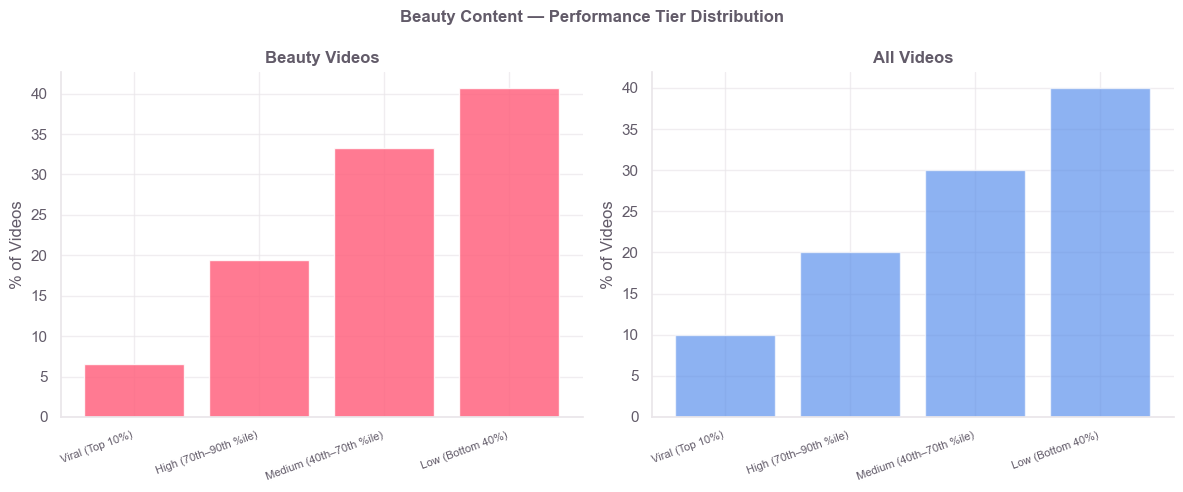

In [34]:
# 6.4 Beauty-specific tier analysis
# Note: df_beauty have to be re-sliced from df_video, so it includes performance_tier

df_beauty = df_video[df_video["is_beauty"]].copy()

beauty_tier  = df_beauty["performance_tier"].value_counts(normalize=True) * 100
overall_tier = df_video["performance_tier"].value_counts(normalize=True) * 100

tier_compare = pd.DataFrame({
    "Beauty %":  beauty_tier.reindex(tier_order),
    "Overall %": overall_tier.reindex(tier_order),
}).fillna(0).round(1)

print("Beauty vs. Overall — Performance Tier Distribution:")
print(tier_compare.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Beauty Content — Performance Tier Distribution", fontsize=12, fontweight="bold")

ax = axes[0]
ax.bar(tier_compare.index, tier_compare["Beauty %"], color=BEAUTY_PINK, alpha=0.85)
ax.set_title("Beauty Videos")
ax.set_ylabel("% of Videos")
ax.set_xticklabels(tier_compare.index, rotation=20, ha="right", fontsize=8)

ax = axes[1]
ax.bar(tier_compare.index, tier_compare["Overall %"], color=BABY_BLUE, alpha=0.65)
ax.set_title("All Videos")
ax.set_ylabel("% of Videos")
ax.set_xticklabels(tier_compare.index, rotation=20, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("charts/06_beauty_tiers.png", dpi=150, bbox_inches="tight")
plt.show()


**Key insight:**  
Beauty content appears slightly over-represented in the higher performance tiers, suggesting that the category is not only engagement-friendly, but also capable of achieving large-scale reach. For brands, this reduces the tradeoff between visibility and audience interaction compared with some other content categories.

**Summary:**  
The Python analysis established the main behavioural patterns in the dataset. The next section demonstrates how similar stakeholder questions can be answered directly in SQL against a structured database environment.

---
## 7. SQL Analysis

This section loads the cleaned dataset into an in-memory SQLite database and runs six business-focused queries, each answering a question a real stakeholder might ask.

In [35]:
# SQLite setup
# Load df_video into an in-memory database and create a reusable query helper

import sqlite3

conn = sqlite3.connect(":memory:")

df_video.to_sql("videos", conn, if_exists="replace", index=False)

def run_sql(query):
    """Run a SQL query and return the result as a DataFrame."""
    return pd.read_sql_query(query, conn)

# Verify the table loaded correctly
check = run_sql("SELECT COUNT(*) AS total_rows FROM videos")
print(f"Table loaded: {check['total_rows'][0]:,} rows")
print()
print("Columns available:")
cols = run_sql("PRAGMA table_info(videos)")
print(cols[["name", "type"]].to_string(index=False))

Table loaded: 6,348 rows

Columns available:
                  name      type
              video_id      TEXT
         trending_date TIMESTAMP
                 title      TEXT
         channel_title      TEXT
           category_id   INTEGER
          publish_time TIMESTAMP
                  tags      TEXT
                 views   INTEGER
                 likes   INTEGER
              dislikes   INTEGER
         comment_count   INTEGER
        thumbnail_link      TEXT
     comments_disabled   INTEGER
      ratings_disabled   INTEGER
video_error_or_removed   INTEGER
           description      TEXT
              category      TEXT
             like_rate      REAL
          dislike_rate      REAL
          comment_rate      REAL
      engagement_score      REAL
         days_to_trend   INTEGER
    trending_day_count   INTEGER
          publish_hour   INTEGER
           publish_day      TEXT
         publish_month      TEXT
             is_beauty   INTEGER
      performance_tier      TEX

---
### Query 1 — Category Leaderboard

**Business question:** Which content categories dominate trending and which attract the most engaged audiences?

Reach (views) and engagement pull in different directions across categories. This query surfaces both so a brand can see where beauty sits relative to the full platform.

In [36]:
q1 = """
SELECT
    category,
    COUNT(*)                                       AS video_count,
    ROUND(AVG(views)            / 1e6, 2)          AS avg_views_M,
    ROUND(AVG(like_rate)        * 100, 2)          AS avg_like_rate_pct,
    ROUND(AVG(engagement_score) * 100, 2)          AS avg_engagement_pct,
    ROUND(AVG(days_to_trend), 1)                   AS avg_days_to_trend,

    -- Rank categories by engagement so stakeholders can scan quickly
    RANK() OVER (ORDER BY AVG(engagement_score) DESC) AS engagement_rank

FROM videos
GROUP BY category
HAVING video_count >= 20          -- exclude categories with too few videos to be meaningful
ORDER BY avg_engagement_pct DESC
LIMIT 12;
"""

display(run_sql(q1))

,category,video_count,avg_views_M,avg_like_rate_pct,avg_engagement_pct,avg_days_to_trend,engagement_rank
0,Music,799,1.39,7.40,8.07,22.7,1
1,Howto & Style,595,0.47,5.14,5.84,5.3,2
2,Comedy,547,0.77,4.97,5.55,10.8,3
3,People & Blogs,498,0.71,4.70,5.30,20.1,4
4,Gaming,103,1.21,4.38,5.29,41.3,5
5,Pets & Animals,138,0.28,4.50,5.04,5.7,6
6,Education,250,0.35,4.18,4.72,61.8,7
7,Science & Technology,380,0.58,3.58,4.10,29.1,8
8,Film & Animation,317,0.92,3.40,3.88,72.3,9
9,Entertainment,1617,0.82,3.21,3.68,18.2,10


**Interpretation:**  This query shows that category size, reach, and engagement do not move together perfectly. Some categories generate strong average views, while others show stronger measured engagement rates. For a beauty brand, this reinforces the need to evaluate categories using both reach and audience response rather than views alone.

---
### Query 2 — Beauty Creator Ranking

**Business question:** Which beauty channels have the strongest combination of reach and audience quality?

Ranking by total views alone would favour large media channels. This query ranks by engagement rate and surfaces reach alongside it, so a brand can evaluate both dimensions at once.

In [37]:
q2 = """
SELECT
    channel_title,
    COUNT(*)                                        AS trending_videos,
    ROUND(SUM(views)            / 1e6, 1)           AS total_views_M,
    ROUND(AVG(views)            / 1e6, 2)           AS avg_views_per_video_M,
    ROUND(AVG(engagement_score) * 100, 2)           AS avg_engagement_pct,
    ROUND(AVG(like_rate)        * 100, 2)           AS avg_like_rate_pct,
    ROUND(AVG(days_to_trend), 1)                    AS avg_days_to_trend

FROM videos
WHERE is_beauty = 1
GROUP BY channel_title
HAVING trending_videos >= 3       -- minimum 3 videos for a reliable channel-level estimate
ORDER BY avg_engagement_pct DESC
LIMIT 15;
"""

display(run_sql(q2))

,channel_title,trending_videos,total_views_M,avg_views_per_video_M,avg_engagement_pct,avg_like_rate_pct,avg_days_to_trend
0,AmazingPhil,3,3.3,1.10,16.55,14.62,3.0
1,Alissa Ashley,4,0.9,0.22,13.29,12.19,1.3
2,Sailor J,6,0.6,0.10,13.16,10.98,2.0
3,Jackie Aina,8,3.2,0.40,12.07,10.72,1.4
4,grav3yardgirl,4,4.7,1.17,11.02,8.79,1.5
5,Queen Naija,3,8.1,2.70,10.96,9.49,2.3
6,jeffreestar,4,6.7,1.68,10.38,6.75,3.0
7,James Charles,14,21.3,1.52,9.94,8.48,2.5
8,NikkieTutorials,12,19.8,1.65,9.91,7.96,2.3
9,JunsKitchen,5,4.6,0.92,9.67,8.99,1.2


**Interpretation:** Channels that rank highly here on engagement but have lower `total_views_M` are the hidden-gem candidates visualised in Section 5.4. The `avg_views_per_video_M` column separates channels that appear frequently with modest videos from those with fewer but larger hits — relevant when deciding whether to pursue a volume partnership or a single large activation.

---
### Query 3 — Hidden-Gem Candidates

**Business question:** Which beauty creators punch above their weight on engagement relative to their reach?

This query applies the same logic as the opportunity matrix in Section 5.4, but in SQL — making it reproducible against any updated dataset.

In [38]:
# First compute the median-equivalent thresholds using Python
# (SQLite has no native MEDIAN — we calculate once and pass into the query)
beauty_channels_temp     = (
    df_video[df_video["is_beauty"] == 1]
    .groupby("channel_title")
    .agg(total_views=("views", "sum"), avg_eng=("engagement_score", "mean"))
    .query("total_views > 0")
)
med_reach_sql  = float(beauty_channels_temp["total_views"].median())
med_eng_sql    = float(beauty_channels_temp["avg_eng"].median())

print(f"Reach threshold (median total views): {med_reach_sql/1e6:.2f}M")
print(f"Engagement threshold (median avg engagement): {med_eng_sql*100:.2f}%")
print()

q3 = f"""
SELECT
    channel_title,
    COUNT(*)                                        AS trending_videos,
    ROUND(SUM(views)            / 1e6, 2)           AS total_views_M,
    ROUND(AVG(engagement_score) * 100, 2)           AS avg_engagement_pct,
    ROUND(AVG(like_rate)        * 100, 2)           AS avg_like_rate_pct,
    ROUND(AVG(days_to_trend),   1)                  AS avg_days_to_trend,

    -- Quadrant label using the same thresholds as Section 5.4
    CASE
        WHEN SUM(views) >= {med_reach_sql}
         AND AVG(engagement_score) >= {med_eng_sql}  THEN 'Tier 1'
        WHEN SUM(views) <  {med_reach_sql}
         AND AVG(engagement_score) >= {med_eng_sql}  THEN 'Hidden Gem'
        WHEN SUM(views) >= {med_reach_sql}
         AND AVG(engagement_score) <  {med_eng_sql}  THEN 'Awareness Play'
        ELSE 'Lower Priority'
    END AS quadrant

FROM videos
WHERE is_beauty = 1
GROUP BY channel_title
HAVING trending_videos >= 3
ORDER BY
    quadrant ASC,
    avg_engagement_pct DESC;
"""

result_q3 = run_sql(q3)

# Show Hidden Gem quadrant first, then full table
print("── Hidden-Gem channels ──")
display(result_q3[result_q3["quadrant"] == "Hidden Gem"].reset_index(drop=True))

print("── Full quadrant breakdown ──")
display(result_q3.reset_index(drop=True))

Reach threshold (median total views): 0.35M
Engagement threshold (median avg engagement): 5.55%

── Hidden-Gem channels ──


,channel_title,trending_videos,total_views_M,avg_engagement_pct,avg_like_rate_pct,avg_days_to_trend,quadrant
0,Kayley Melissa,3,0.08,8.94,8.07,1.0,Hidden Gem
1,Buttered Side Down,3,0.17,8.64,7.74,1.3,Hidden Gem
2,Joan Kim,3,0.17,7.40,6.62,2.0,Hidden Gem
3,Laura Kampf,3,0.24,7.00,6.48,1.3,Hidden Gem
4,The Scran Line,8,0.23,6.97,6.07,1.5,Hidden Gem
5,CupcakeJemma,5,0.32,6.01,5.79,2.2,Hidden Gem
6,Laura in the Kitchen,4,0.20,5.78,5.37,1.0,Hidden Gem


── Full quadrant breakdown ──


,channel_title,trending_videos,total_views_M,avg_engagement_pct,avg_like_rate_pct,avg_days_to_trend,quadrant
0,GreatScott!,3,0.49,5.54,4.97,4.0,Awareness Play
1,Brad Mondo,3,1.03,5.51,4.77,3.0,Awareness Play
2,Tina Yong,3,1.04,5.43,5.01,2.0,Awareness Play
3,How To Cook That,4,0.45,5.36,4.44,1.0,Awareness Play
4,emmymadeinjapan,6,0.70,5.26,4.34,2.3,Awareness Play
...,...,...,...,...,...,...,...
84,ThreadBanger,9,6.65,5.96,5.46,1.9,Tier 1
85,Sprinkleofglitter,3,1.31,5.91,5.28,2.0,Tier 1
86,TheSorryGirls,4,0.52,5.85,5.48,2.3,Tier 1
87,heyitsfeiii,3,0.95,5.78,5.54,2.3,Tier 1


**Interpretation:** The Hidden Gem rows here should align with the top-left quadrant in the scatter plot from Section 5.4 — if the thresholds are consistent, they will. Surfacing this in SQL means the list can be refreshed instantly on a new dataset without redrawing the chart. For a brand analyst, this is the most directly actionable query in the section.

---
### Query 4 — Performance Tier Breakdown

**Business question:** Beyond views, what actually separates high-performing videos from low ones?

Tiers are defined by views, so this query deliberately focuses on the behavioural metrics — engagement rate, trending speed, and staying power — that a brand can use to set expectations when briefing a creator.

In [39]:
q4 = """
SELECT
    performance_tier,
    COUNT(*)                                        AS video_count,

    -- Engagement quality
    ROUND(AVG(like_rate)          * 100, 2)         AS avg_like_rate_pct,
    ROUND(AVG(engagement_score)   * 100, 2)         AS avg_engagement_pct,

    -- Speed to trend
    ROUND(AVG(days_to_trend), 1)                    AS avg_days_to_trend,

    -- What share hit trending within 2 days?
    ROUND(SUM(CASE WHEN days_to_trend <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),1)                 
                                                    AS pct_viral_within_2_days,

    -- Staying power
    ROUND(AVG(trending_day_count), 1)               AS avg_trending_duration

FROM videos
GROUP BY performance_tier
ORDER BY avg_engagement_pct DESC;
"""

display(run_sql(q4))

,performance_tier,video_count,avg_like_rate_pct,avg_engagement_pct,avg_days_to_trend,pct_viral_within_2_days,avg_trending_duration
0,Viral (Top 10%),635,4.72,5.28,2.2,76.7,8.7
1,High (70th–90th %ile),1270,4.26,4.83,2.1,77.5,7.7
2,Medium (40th–70th %ile),1904,4.10,4.60,5.6,77.1,6.8
3,Low (Bottom 40%),2539,3.69,4.30,50.6,68.1,5.0


**Interpretation:** The `pct_viral_within_2_days` column is the most actionable figure here. If viral-tier videos disproportionately hit trending within 48 hours, it confirms that early amplification — not slow organic build — is the dominant path to the top tier. A brand that front-loads promotion in the first two days after a creator uploads is acting on this finding; one that waits a week is not.

---
### Query 5 — Publish Timing Patterns (Beauty)

**Business question:** Do beauty videos published on certain days tend to reach trending faster or accumulate more views?

> **Caveat:** Publish-day patterns are directional signals, not precise prescriptions. Category mix, creator schedules, and audience behaviour all confound this — interpret as a starting point for further investigation, not a hard rule.

In [40]:
q5 = """
SELECT
    publish_day,
    COUNT(*)                                        AS video_count,
    ROUND(AVG(views)            / 1e6, 2)           AS avg_views_M,
    ROUND(AVG(engagement_score) * 100, 2)           AS avg_engagement_pct,
    ROUND(AVG(days_to_trend),   1)                  AS avg_days_to_trend,

    -- What share reached trending within 2 days?
    ROUND(SUM(CASE WHEN days_to_trend <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),1)         
                                                    AS pct_trending_within_2_days

FROM videos
WHERE is_beauty = 1
  AND publish_day IS NOT NULL
GROUP BY publish_day
ORDER BY avg_engagement_pct DESC;
"""

display(run_sql(q5))

,publish_day,video_count,avg_views_M,avg_engagement_pct,avg_days_to_trend,pct_trending_within_2_days
0,Friday,111,0.68,6.56,2.3,71.2
1,Wednesday,154,0.43,6.09,8.5,76.6
2,Saturday,112,0.81,6.09,2.1,76.8
3,Thursday,130,0.53,6.06,6.1,66.2
4,Tuesday,142,0.44,5.63,5.1,71.1
5,Monday,92,0.38,5.50,2.1,73.9
6,Sunday,82,0.68,5.41,2.4,67.1


**Interpretation:**  
This table should be read as an observed timing pattern rather than a publishing rule. `pct_trending_within_2_days` is more useful than average views because average views can be distorted by a small number of outlier videos. If certain days show higher early-trending rates, they may be worth testing in future campaign planning, but this dataset alone cannot prove that the day itself caused better performance.

---
### Query 6 — Viral Speed by Category

**Business question:** Which content categories generate early momentum fastest — and how does beauty compare?

Early trending speed reflects social momentum at launch: shares, comments, and algorithmic pickup in the first 48 hours. Categories with fast trending times likely benefit from highly networked, reactive audiences.

In [41]:
q6 = """
SELECT
    category,
    COUNT(*)                                        AS video_count,
    ROUND(AVG(days_to_trend), 2)                    AS avg_days_to_trend,

    -- Percentage that hit trending within 1 day (immediate viral)
    ROUND(SUM(CASE WHEN days_to_trend <= 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),1)                    
                                                    AS pct_within_1_day,

    -- Percentage that hit trending within 2 days
    ROUND(SUM(CASE WHEN days_to_trend <= 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),1)     
                                                    AS pct_within_2_days,

    -- Percentage that took more than 7 days (slow burn)
    ROUND(SUM(CASE WHEN days_to_trend > 7  THEN 1 ELSE 0 END) * 100.0 / COUNT(*),1)       
                                                    AS pct_slow_burn

FROM videos
GROUP BY category
HAVING video_count >= 20
ORDER BY avg_days_to_trend ASC
LIMIT 12;
"""

display(run_sql(q6))

,category,video_count,avg_days_to_trend,pct_within_1_day,pct_within_2_days,pct_slow_burn
0,Travel & Events,60,4.18,31.7,61.7,8.3
1,Howto & Style,595,5.32,40.8,73.8,2.5
2,Pets & Animals,138,5.73,30.4,60.9,5.1
3,Comedy,547,10.76,52.3,81.7,1.3
4,News & Politics,505,15.00,51.9,77.8,1.6
5,Entertainment,1617,18.17,45.8,75.9,2.5
6,Sports,451,20.01,56.1,80.5,2.9
7,People & Blogs,498,20.12,38.6,67.7,4.8
8,Music,799,22.69,50.8,73.7,2.3
9,Science & Technology,380,29.13,30.8,60.8,7.1


**Interpretation:** Categories near the top of this table (lowest `avg_days_to_trend`) have audiences that react immediately — Music and Entertainment fans share and comment within hours of upload. If beauty content trends more slowly than these categories, it suggests audience activation requires more deliberate seeding (notifications, community posts, cross-platform sharing) rather than purely passive reach. A brand working with a beauty creator should build that activation into the launch plan rather than assuming organic momentum will carry it.

---
## 8. Interactive Tableau Dashboard

A Tableau dashboard was developed to operationalise the project's analytical outputs and support creator partnership evaluation.

The dashboard consists of four components:

- **Creator Opportunity Matrix**
- **Hidden Gem Creator Shortlist**
- **Beauty Over-Indexes: Engagement vs Reach**
- **48-Hour Viral Window**

These views support creator prioritisation, performance benchmarking, and trending-speed assessment within a single decision-support interface.

<img src="dashboard/Tableau_Dashboard.png" width="1000">

---
## 9. Strategic Recommendations

Three decisions follow directly from this analysis: which creators to partner with, how to structure partnership allocation, and when to activate campaigns. The recommendations below address each in turn.

---

### Recommendation 1 — Restructure the Creator Selection Process Around Engagement, Not Views

**Evidence:** The correlation analysis in Section 4 establishes the foundation for this recommendation: `engagement_score` shows near-zero correlation with raw view counts, meaning the two metrics are capturing different audience behaviours rather than reinforcing the same signal.

A shortlist built primarily on subscriber counts or total views will therefore systematically favour visibility over audience responsiveness. For campaigns where interaction, trust, and active audience participation matter, engagement rate — `(likes + comments) / views` — is the more commercially relevant metric.

**Action:** Replace views-based ranking as the primary creator selection criterion with a combined scorecard that weights `engagement_score` alongside reach. The SQL analyses in Section 7 (Queries 2 and 3) provide a reusable framework for this evaluation approach.

---

### Recommendation 2 — Adopt a Two-Tier Partnership Strategy, and Prioritise the Hidden-Gem Tier

**Evidence:** The opportunity matrix in Section 5 identifies a distinct group of beauty creators — above-median engagement, below-median reach — who deliver audience responsiveness comparable to much larger partners. These channels are the most likely to be underpriced in the influencer market because creator pricing remains heavily reach-driven.

A single-tier strategy focused only on the largest channels concentrates budget where competition is highest and engagement efficiency is often lower. A two-tier structure allocates partnership spend more strategically.

- **Tier 1 — Reach:** Large beauty creators suitable for awareness-led campaigns where impression volume and broad visibility are the primary objectives.
- **Tier 2 — Engagement (Hidden Gems):** Mid-sized creators in the top-left quadrant of the opportunity matrix, where engagement remains high while partnership costs are likely lower. These creators are the stronger fit for product launches, conversion-focused campaigns, and activations where audience trust matters more than maximum reach.

**Action:** Use the hidden-gem creator shortlist (Section 5 and SQL Query 3) as the starting point for Tier 2 outreach. Apply a minimum video threshold (≥ 3 trending videos) to reduce the influence of one-off viral outliers and stabilise the engagement signal.

---

### Recommendation 3 — Treat the 48-Hour Post-Upload Window as the Critical Activation Moment

**Evidence:** Over 70% of trending beauty videos reach the trending page within two days of publishing. Beauty content also appears to have a shorter effective viral window than categories such as Music or Entertainment, where momentum builds differently and remains active for longer periods. Delayed amplification — paid promotion, PR outreach, or cross-channel sharing scheduled days after upload — often arrives after the highest-leverage engagement window has already passed.

The compounding effect makes timing especially important. Viral-tier videos do not simply accumulate more views initially — they remain on trending for substantially longer, extending their visibility advantage over time. Early amplification therefore increases both immediate exposure and the probability of sustained momentum.

**Actions:**
- Coordinate campaign activation with creator upload schedules rather than fixed campaign calendar dates. Paid amplification and cross-channel promotion should be prepared in advance and deployed within 24–48 hours of a creator publishing. If upload timing changes, the activation schedule should shift with it.
- Track `trending_day_count` alongside total views for partnered content. Videos that trend early and sustain position should be treated as candidates for increased amplification investment rather than evaluated only after final performance stabilises.

---

### A Note on These Recommendations

These findings are directional. The dataset covers November 2017 – June 2018, and the YouTube algorithm, creator ecosystem, and beauty category have evolved significantly since then. The analytical framework — separating engagement quality from reach, identifying the engagement–reach disconnect, and analysing the front-loaded viral window — remains valid methodology. However, the specific channel rankings, engagement thresholds, and timing benchmarks should be recalibrated against current data before informing material budget decisions.

The engagement metrics used throughout this analysis (likes, comments, views) are also proxies rather than direct measures of commercial intent. High engagement correlates with audience responsiveness and active interest, but it does not guarantee conversion. Real partnership decisions should therefore combine quantitative analysis with qualitative assessment of audience demographics, content style, creator reputation, and brand alignment.

---

## Final Strategic Takeaway

The standard playbook for YouTube influencer partnerships starts with reach: identify the largest creators in a category, negotiate based on audience size, and evaluate success primarily through impressions. For beauty brands, the data suggests that approach leaves meaningful value on the table.

The central finding of this analysis is not that large beauty creators are ineffective partners — many combine strong reach with strong engagement. It is that **reach and engagement are weakly correlated enough that optimising for one does not reliably deliver the other**, and that a meaningful segment of mid-sized creators consistently delivers above-median audience responsiveness despite remaining below-median on total reach. If partnership pricing remains primarily visibility-driven, these creators are systematically undervalued.

The most actionable output of this project is therefore the hidden-gem creator framework developed in Section 5 and operationalised in SQL Query 3. A creator selection process built around engagement responsiveness rather than reach alone produces a materially different — and more strategically valuable — shortlist than conventional reach-first filtering.

The second major implication is timing. Beauty content’s viral momentum is highly front-loaded, meaning that amplification strategy matters most during the first 48 hours after upload. Brands that align campaign activation with creator publishing behaviour — rather than static campaign schedules — are acting on how the platform’s momentum dynamics actually function.

---

*For this analysis to move from exploratory to operational, two additions would strengthen it materially: current post-2020 platform data, and audience-level demographic or conversion data capable of validating whether highly engaged audiences also align with a beauty brand’s target customer profile. Neither limitation invalidates the analytical framework itself, but both would influence the specific thresholds, creator rankings, and activation benchmarks used in practice.*

---

In [42]:
# Export for Tableau Dashboard

# 1. Video-level export ────────────────────────────────────────────────────────────
# one row per unique video
# Use for: timing chart, tier analysis, slicers, % trending within 2 days

video_cols = [
    "video_id", "title", "channel_title", "category",
    "views", "likes", "comment_count",
    "like_rate", "comment_rate", "engagement_score",
    "days_to_trend", "trending_day_count",
    "publish_day", "publish_hour", "publish_month",
    "is_beauty", "performance_tier"
]

video_export = df_video[video_cols].copy()
video_export.to_csv("tableau_video_level.csv", index=False)


# 2. Creator-level export ──────────────────────────────────────────────────────────
# one row per beauty channel
# Use for: creator opportunity matrix, hidden-gem table

creator_export = (
    df_video[df_video["is_beauty"] == 1]
    .groupby("channel_title")
    .agg(
        video_count=        ("video_id",              "count"),
        total_views=        ("views",                 "sum"),
        avg_views=          ("views",                 "mean"),
        avg_engagement=     ("engagement_score",      "mean"),
        avg_like_rate=      ("like_rate",             "mean"),
        avg_comment_rate=   ("comment_rate",          "mean"),
        avg_days_to_trend=  ("days_to_trend",         "mean"),
        avg_trending_days=  ("trending_day_count",    "mean")
    )
    .reset_index()
    .query("video_count >= 3")
    .copy()
)

# Median thresholds for quadrant classification
med_views = creator_export["total_views"].median()
med_eng = creator_export["avg_engagement"].median()

creator_export["quadrant"] = np.select(
    [(creator_export["total_views"] >= med_views) & (creator_export["avg_engagement"] >= med_eng),
     (creator_export["total_views"] <  med_views) & (creator_export["avg_engagement"] >= med_eng),
     (creator_export["total_views"] >= med_views) & (creator_export["avg_engagement"] <  med_eng),
    ],
    ["Tier 1",
     "Hidden Gem",
     "Awareness Play"
    ],
    default="Lower Priority"
)

# Add display-friendly fields for Tableau labels/tooltips
creator_export["total_views_M"] = creator_export["total_views"] / 1e6
creator_export["avg_views_M"] = creator_export["avg_views"] / 1e6
creator_export["avg_engagement_pct"] = creator_export["avg_engagement"] * 100
creator_export["avg_like_rate_pct"] = creator_export["avg_like_rate"] * 100
creator_export["avg_comment_rate_pct"] = creator_export["avg_comment_rate"] * 100

# Store thresholds for reference lines
creator_export["med_views_threshold"] = med_views
creator_export["med_eng_threshold"] = med_eng
creator_export["med_eng_threshold_pct"] = med_eng * 100

creator_export.to_csv("tableau_creator_level.csv", index=False)


# 3. Category-level export ─────────────────────────────────────────────────────────
# one row per category
# Use for: beauty vs platform/category comparison

category_export = (
    df_video.groupby("category")
    .agg(
        video_count=         ("video_id",           "count"),
        avg_views=           ("views",              "mean"),
        median_views=        ("views",              "median"),
        avg_engagement=      ("engagement_score",   "mean"),
        median_engagement=   ("engagement_score",   "median"),
        avg_like_rate=       ("like_rate",          "mean"),
        avg_comment_rate=    ("comment_rate",       "mean"),
        avg_days_to_trend=   ("days_to_trend",      "mean")
    )
    .reset_index()
)

category_export["is_howto_style"] = category_export["category"].eq("Howto & Style").astype(int)
category_export.to_csv("tableau_category_summary.csv", index=False)


# 4. Beauty vs non-beauty indexed comparison ───────────────────────────────────────
# one row per metric
# Use for: indexed bar chart, baseline = non-beauty = 100

beauty_group = df_video[df_video["is_beauty"] == 1]
non_beauty_group = df_video[df_video["is_beauty"] == 0]

index_rows = []

metrics = {
    "Median Views":             ("views",             "median"),
    "Median Like Rate":         ("like_rate",         "median"),
    "Median Engagement Score":  ("engagement_score",  "median"),
    "Median Comment Rate":      ("comment_rate",      "median")
}

for metric_name, (col, agg_func) in metrics.items():
    beauty_value = getattr(beauty_group[col], agg_func)()
    non_beauty_value = getattr(non_beauty_group[col], agg_func)()
    index_value = (beauty_value / non_beauty_value) * 100 if non_beauty_value != 0 else np.nan

    index_rows.append({
        "metric": metric_name,
        "beauty_value": beauty_value,
        "non_beauty_value": non_beauty_value,
        "beauty_index": index_value,
        "baseline": 100
    })

index_export = pd.DataFrame(index_rows)
index_export.to_csv("tableau_beauty_index.csv", index=False)


# 5. Timing export ─────────────────────────────────────────────────────────────────
# one row per days_to_trend + beauty flag
# Use for: 48-hour viral window chart

timing_export = (
    df_video
    .assign(
        beauty_group=np.where(df_video["is_beauty"] == 1, "Beauty", "Non-beauty"),
        within_2_days=np.where(df_video["days_to_trend"] <= 2, 1, 0)
    )
    .groupby(["beauty_group", "days_to_trend"])
    .agg(
        video_count=         ("video_id",            "count"),
        avg_engagement=      ("engagement_score",    "mean"),
        avg_views=           ("views",               "mean"),
        pct_within_2_days=   ("within_2_days",       "mean")
    )
    .reset_index()
)
# Total videos within each group
group_totals = (
    timing_export
    .groupby("beauty_group")["video_count"]
    .sum()
)

# Share of each group's videos by days_to_trend
# Example: 0.42 means 42% of that group trends on that day
timing_export["pct_of_group"] = (
    timing_export["video_count"]
    / timing_export["beauty_group"].map(group_totals)
)

timing_export.to_csv("tableau_timing_summary.csv", index=False)


# 6. Tier summary export ───────────────────────────────────────────────────────────
# Grain: one row per performance tier
# Use for: performance tier comparison / trending duration

tier_export = (
    df_video.groupby("performance_tier")
    .agg(
        video_count=         ("video_id",            "count"),
        avg_views=           ("views",               "mean"),
        median_views=        ("views",               "median"),
        avg_engagement=      ("engagement_score",    "mean"),
        median_engagement=   ("engagement_score",    "median"),
        avg_like_rate=       ("like_rate",           "mean"),
        avg_days_to_trend=   ("days_to_trend",       "mean"),
        avg_trending_days=   ("trending_day_count",  "mean"),
        pct_beauty=          ("is_beauty",           "mean")
    )
    .reset_index()
)

tier_export["pct_beauty"] = tier_export["pct_beauty"] * 100
tier_export.to_csv("tableau_tier_summary.csv", index=False)


# Export summary ───────────────────────────────────────────────────────────────────
print("Tableau export complete.")
print()
print(f"tableau_video_level.csv      → {len(video_export):,} rows")
print(f"tableau_creator_level.csv    → {len(creator_export):,} rows")
print(f"tableau_category_summary.csv → {len(category_export):,} rows")
print(f"tableau_beauty_index.csv     → {len(index_export):,} rows")
print(f"tableau_timing_summary.csv   → {len(timing_export):,} rows")
print(f"tableau_tier_summary.csv     → {len(tier_export):,} rows")
print()
print(f"Creator median reach threshold: {med_views/1e6:.2f}M views")
print(f"Creator median engagement threshold: {med_eng*100:.2f}%")
print()
print("Creator quadrant counts:")
print(creator_export["quadrant"].value_counts())

Tableau export complete.

tableau_video_level.csv      → 6,348 rows
tableau_creator_level.csv    → 89 rows
tableau_category_summary.csv → 16 rows
tableau_beauty_index.csv     → 4 rows
tableau_timing_summary.csv   → 139 rows
tableau_tier_summary.csv     → 4 rows

Creator median reach threshold: 1.66M views
Creator median engagement threshold: 5.85%

Creator quadrant counts:
quadrant
Tier 1            28
Lower Priority    27
Awareness Play    17
Hidden Gem        17
Name: count, dtype: int64
